## Import

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "mass_smaller_3"
output_parameters = ['mass', 'radius']
categories_name = ["label"]

In [ ]:
override = True
use_preds = False
save = True
show = True

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading PARSEC dataframe from csv file...


,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.00000,3.4744,2.965,0.0,-0.25,0.090,0.213783
1,5.00000,3.4752,2.963,0.0,-0.25,0.092,0.219060
2,5.00000,3.4780,2.956,0.0,-0.25,0.098,0.236789
3,5.00000,3.4789,2.954,0.0,-0.25,0.100,0.242293
4,5.00000,3.4819,2.950,0.0,-0.25,0.106,0.257918
...,...,...,...,...,...,...,...
681298,10.25002,3.4812,0.032,7.0,0.50,0.801,2.156549
681299,10.25002,3.4776,-0.004,7.0,0.50,0.801,2.175802
681300,10.25002,3.4742,-0.038,7.0,0.50,0.800,2.194514
681301,10.25002,3.4701,-0.077,7.0,0.50,0.800,2.215902


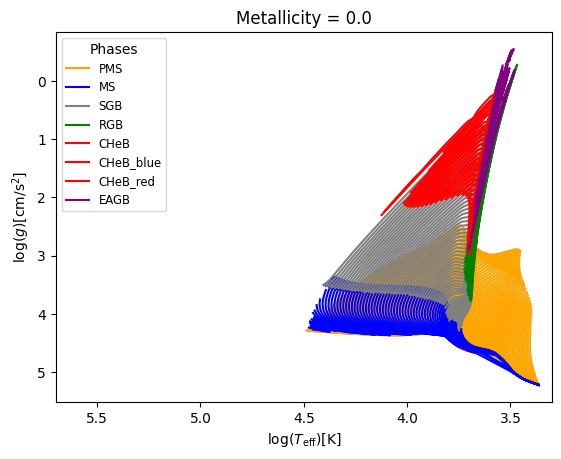

In [4]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.60000,4.4269,4.356,1.0,-0.25,9.714,0.535041
1,5.65000,4.4266,4.355,1.0,-0.25,9.714,0.535800
2,5.70000,4.4263,4.353,1.0,-0.25,9.714,0.536558
3,5.75000,4.4061,4.358,1.0,-0.25,8.856,0.514282
4,5.75000,4.4260,4.352,1.0,-0.25,9.714,0.537441
...,...,...,...,...,...,...,...
321691,10.25002,3.6561,2.334,4.0,0.50,0.805,1.005181
321692,10.25002,3.6560,2.333,4.0,0.50,0.805,1.005609
321693,10.25002,3.6559,2.331,4.0,0.50,0.805,1.006466
321694,10.25002,3.6558,2.330,4.0,0.50,0.805,1.006894


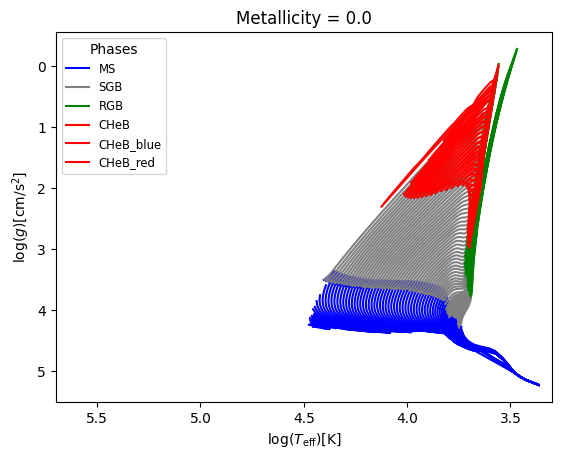

In [5]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,6.80001,4.1048,4.436,1.0,-0.25,2.687,0.215638
1,6.85001,4.1046,4.435,1.0,-0.25,2.687,0.216166
2,6.90001,4.1043,4.434,1.0,-0.25,2.687,0.216694
3,6.90001,4.1083,4.434,1.0,-0.25,2.725,0.220108
4,6.95001,4.1041,4.433,1.0,-0.25,2.687,0.217221
...,...,...,...,...,...,...,...
243958,10.25002,3.6561,2.334,4.0,0.50,0.805,1.005181
243959,10.25002,3.6560,2.333,4.0,0.50,0.805,1.005609
243960,10.25002,3.6559,2.331,4.0,0.50,0.805,1.006466
243961,10.25002,3.6558,2.330,4.0,0.50,0.805,1.006894


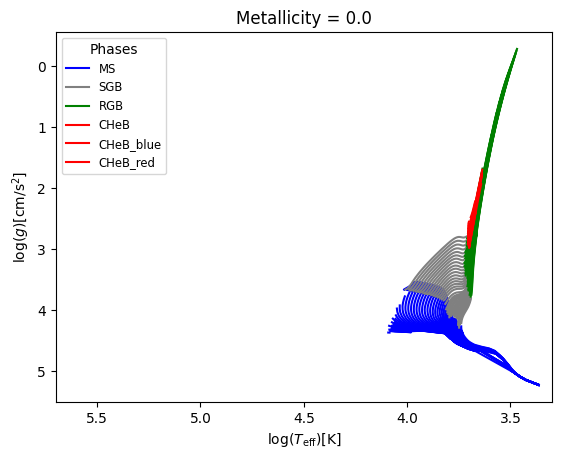

In [7]:
phase_mass_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6], "Mass" : ("<", 3)})
display(phase_mass_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_mass_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
print_all_uniques(phase_mass_filtered_iso_df)

logAge  : Range : 6.8 - 10.25, Mean : 9.4807, Median : 9.5

logTe  : Range : 3.36 - 4.1907, Mean : 3.732, Median : 3.7204

logg  : Range : -0.38 - 5.345, Mean : 2.8946, Median : 2.504

Values in label column : 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.25, -2.5, -2.75, 0.0, 0.25, 0.5 

Mass  : Range : 0.09 - 2.999, Mean : 1.3031, Median : 1.178

Rpol  : Range : -0.98 - 2.3632, Mean : 0.8085, Median : 1.0017



In [9]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_mass_filtered_iso_df, x_cols=['logAge', 'logTe', 'logg', 'metallicity'], 
                               y_cols=['Mass', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the Mass parameter : 0.09 - 2.999
Median value in train data for the Mass parameter: 1.179
Mean value in train data for the Mass parameter: 1.3036826782239908

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.363235804483694
Median value in train data for the Rpol parameter: 1.0017337128090005
Mean value in train data for the Rpol parameter: 0.8081824956202829

Testing set statistics:
Range in test data for the Mass parameter : 0.09 - 2.999
Median value in test data for the Mass parameter: 1.174
Mean value in test data for the Mass parameter: 1.3014723647751307

Range in test data for the Rpol parameter : -0.9763360818022064 - 2.336259552014193
Median value in test data for the Rpol parameter: 1.0021660617565078
Mean value in test data for the Rpol parameter: 0.8093982982620794

(182972, 4) (60991, 4)
(182972, 2) (60991, 2)


## Model training

### Linear regression

In [10]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 2.999
  RVE :  0.6611637557456042
  RMSE :  0.37973772350493834
  MAE :  0.2880276381631927
  MedAE :  0.23494432335679732
  CORR :  0.8695920943962187
  MAX_ER :  1.6127551731539427
  Percentiles : 
    75th percentile :  0.3860504358252852
    90th percentile :  0.614198243637958
    95th percentile :  0.8110251649148058
    99th percentile :  1.1406539396723356

mass results for the label category with a value of 2.0
  value range :  0.726 - 2.996
  RVE :  0.9233322195098903
  RMSE :  0.2709853438680536
  MAE :  0.21390872950799075
  MedAE :  0.17897850878126775
  CORR :  0.96474168346435
  MAX_ER :  0.8713407094861472
  Percentiles : 
    75th percentile :  0.30200874580756365
    90th percentile :  0.4578945575597145
    95th percentile :  0.5572122378873429
    99th percentile :  0.7000978161142156

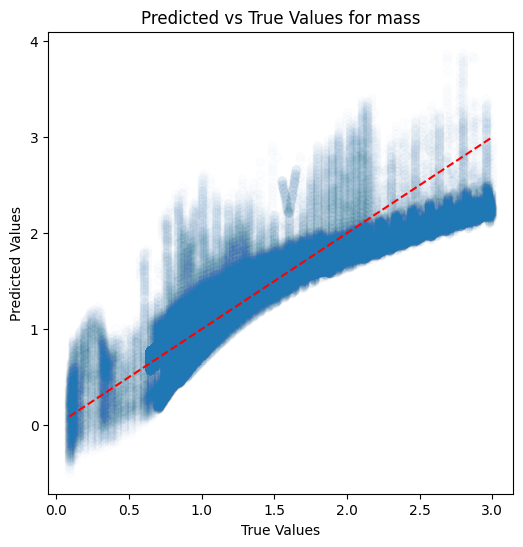

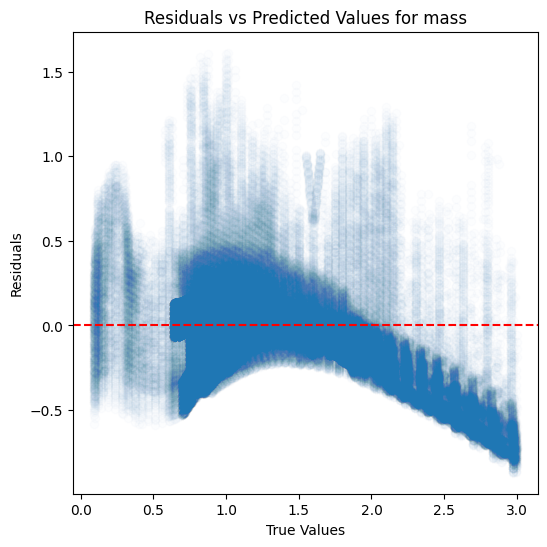

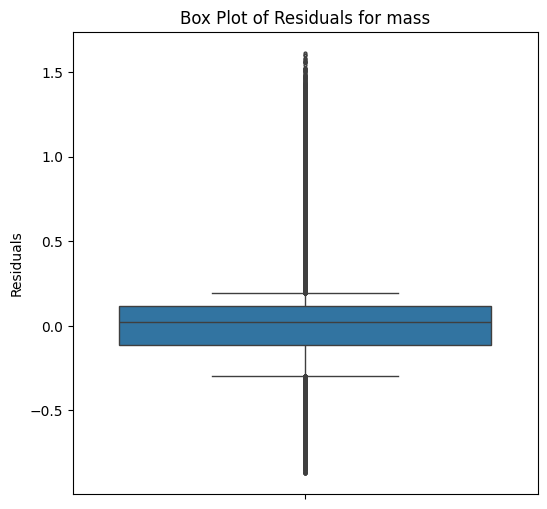

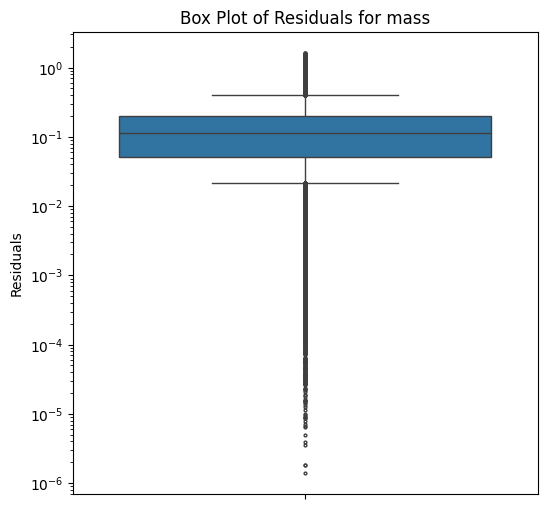

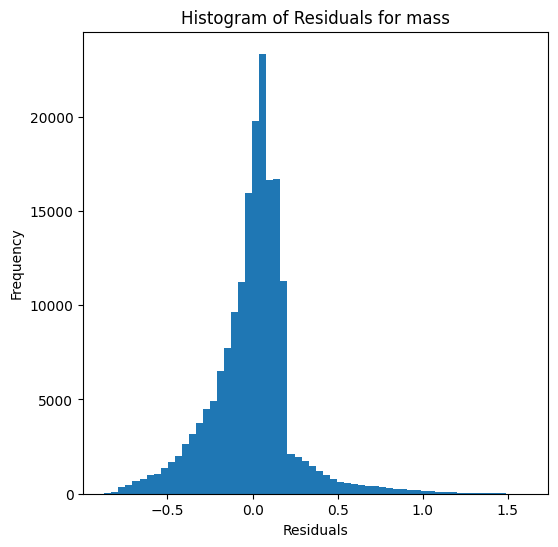

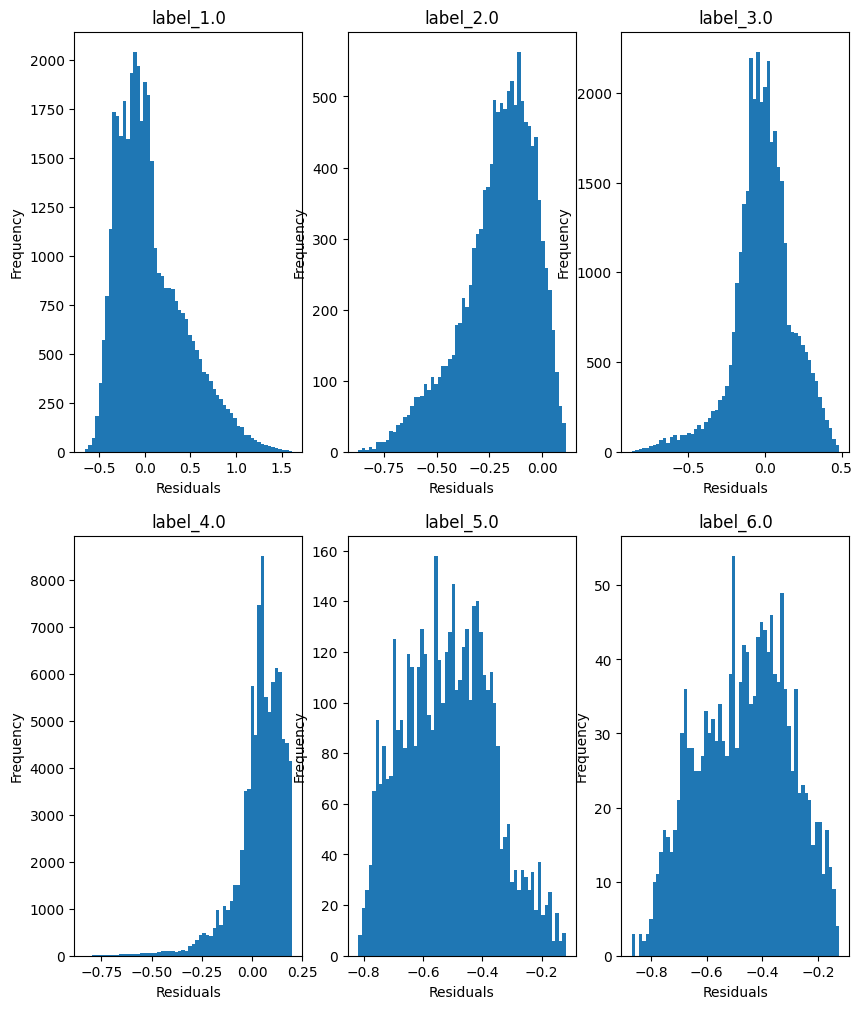

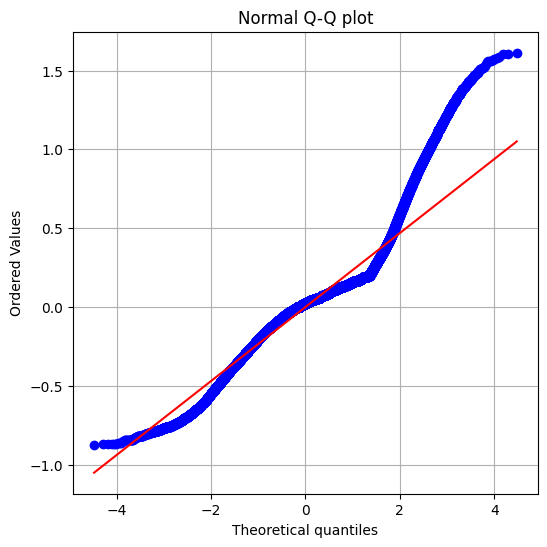

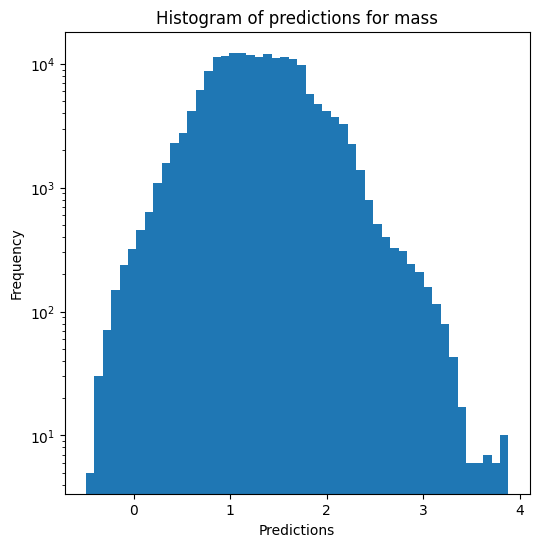

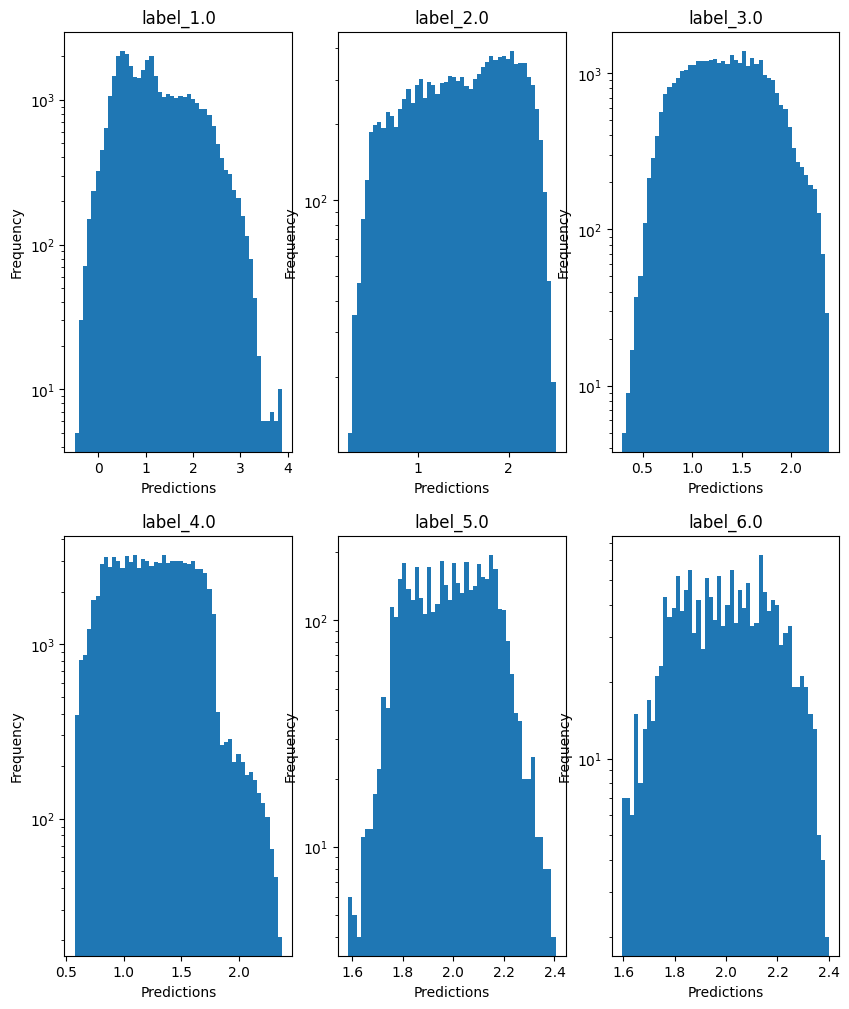

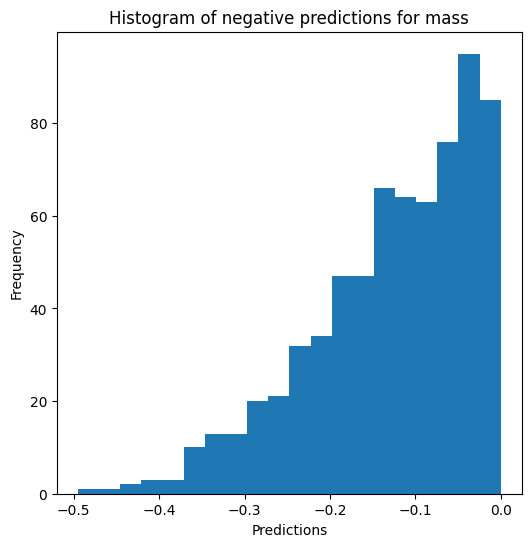


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 0.7228806106869394
  RVE :  0.9359057168106971
  RMSE :  0.07692690266935816
  MAE :  0.05907388999221595
  MedAE :  0.0488720377895618
  CORR :  0.9681394371540123
  MAX_ER :  0.3049602043335856
  Percentiles : 
    75th percentile :  0.07656075641249863
    90th percentile :  0.12336082624049245
    95th percentile :  0.16728215112006453
    99th percentile :  0.23773761371740879

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 1.2289134059946882
  RVE :  0.9848676500607558
  RMSE :  0.04248635880309964
  MAE :  0.03614954928044462
  MedAE :  0.035048729090374514
  CORR :  0.9929563927643908
  MAX_ER :  0.0927206479456104
  Percentiles : 
    75th percentile :  0.05266804229224867
    90th percentile :  0.06823338340430632
    95th percentile :  0.07548236018029973
    99th percentile :  0.0840569658466708

radius results for the label cate

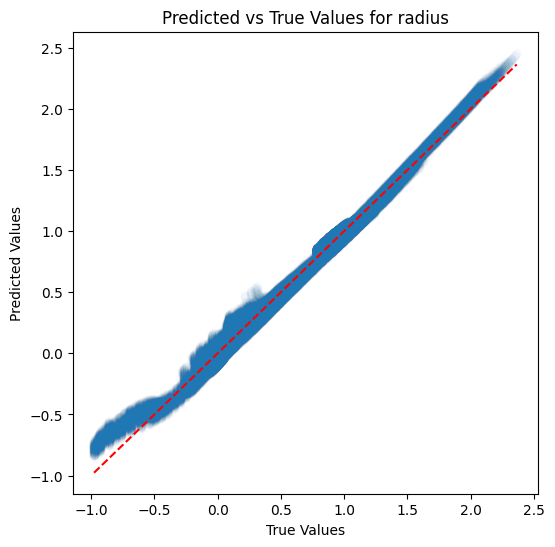

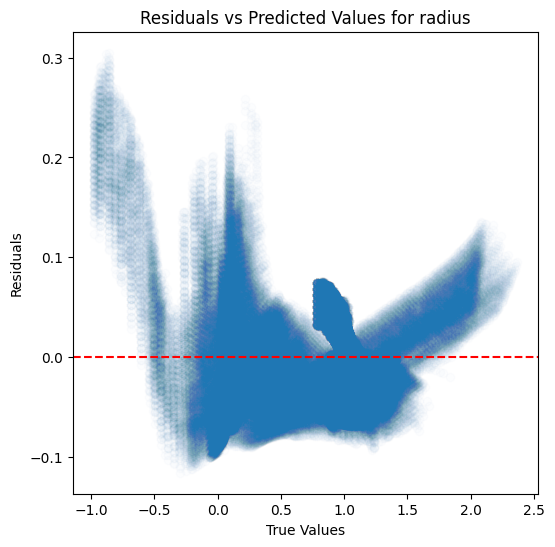

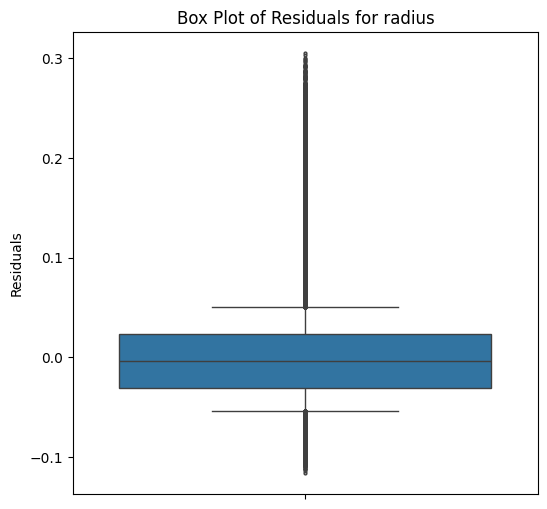

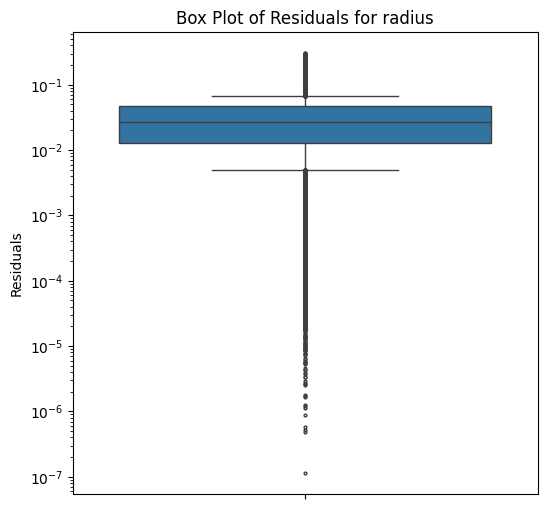

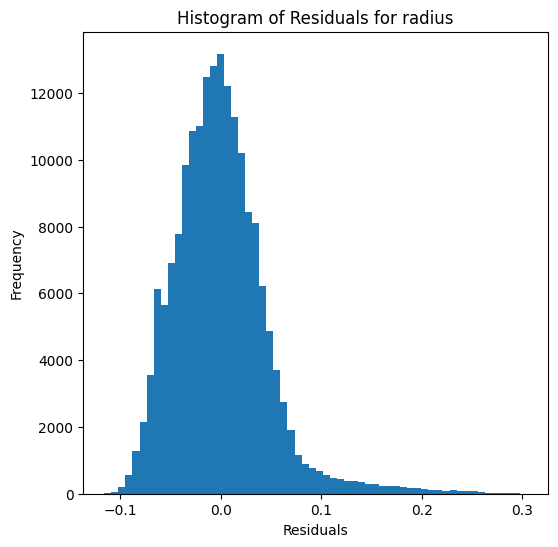

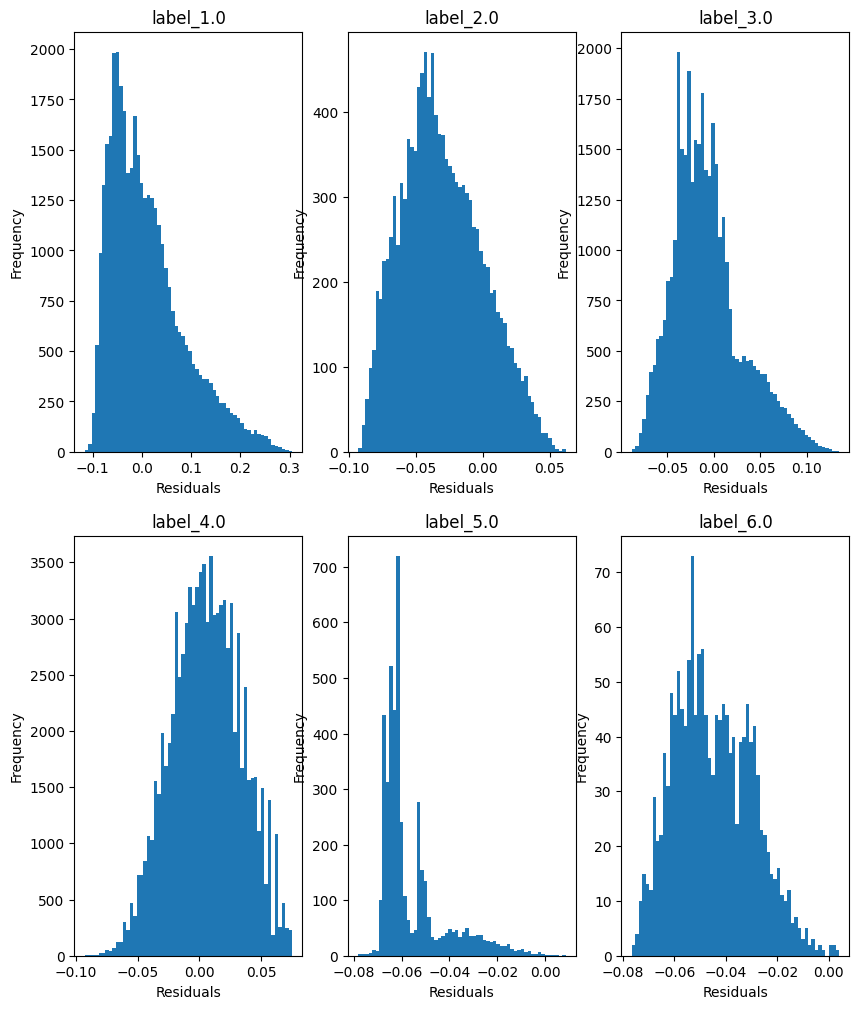

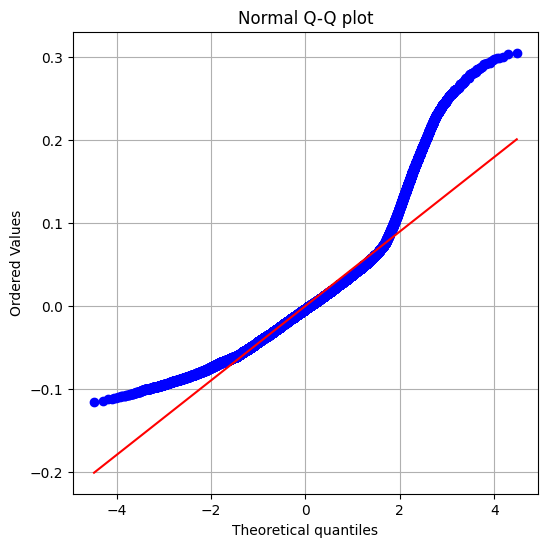

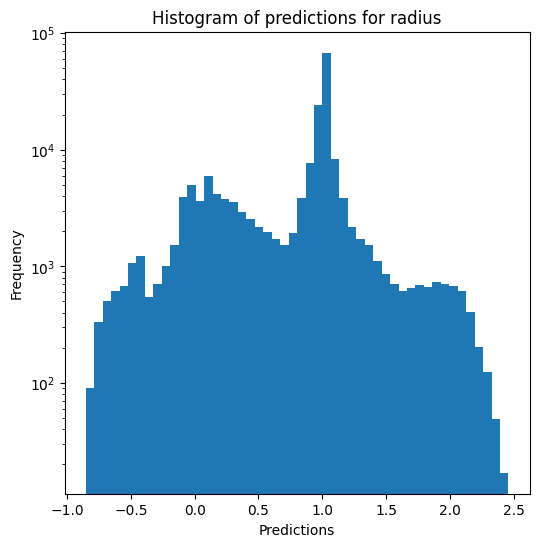

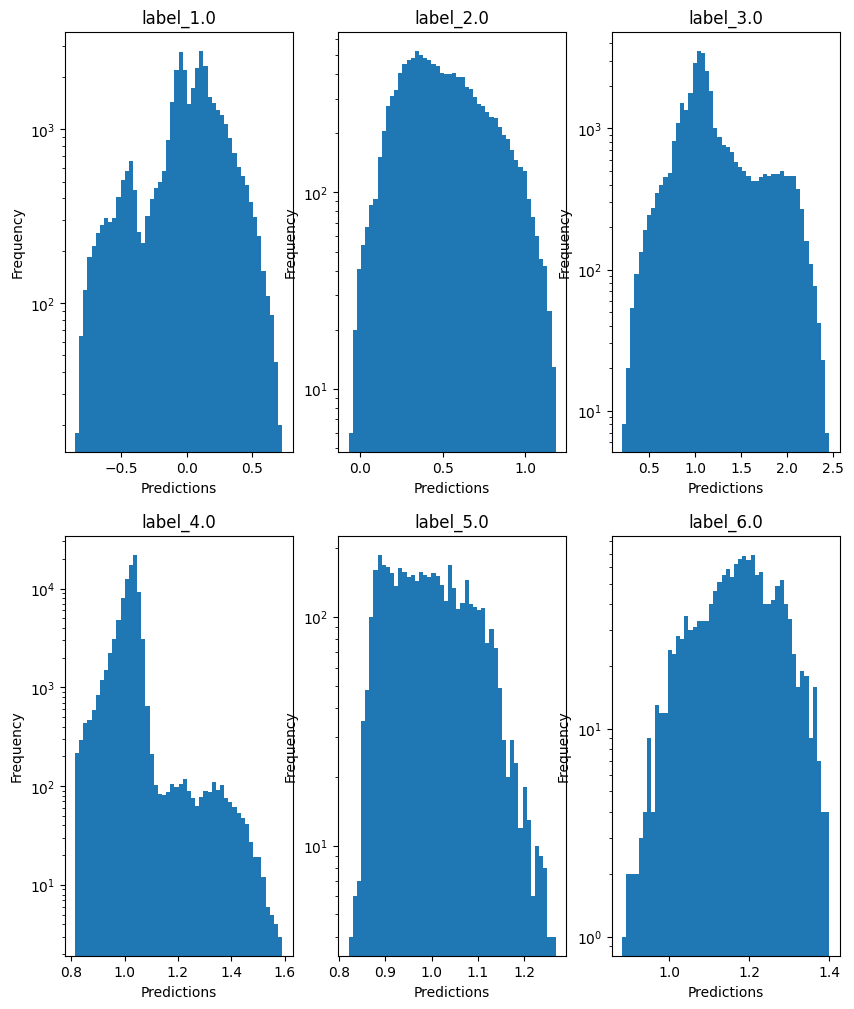

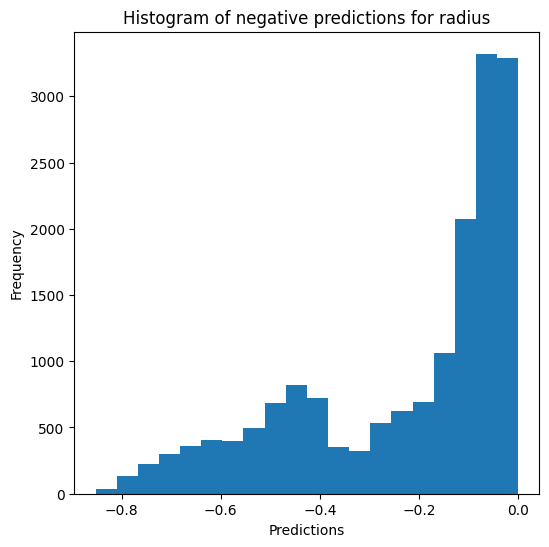

Saving predictions and results...
True
True
True
True


In [ ]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show) #, override=False, use_preds=True)

### Decision tree

In [12]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


no negative values

mass results for the label category with a value of 1.0
  value range :  0.09 - 2.999
  RVE :  0.9996015588887927
  RMSE :  0.012820296118616454
  MAE :  0.0035584884648051022
  MedAE :  0.0
  CORR :  0.9998008347548047
  MAX_ER :  0.3129999999999997
  Percentiles : 
    75th percentile :  0.0009999999999998899
    90th percentile :  0.010000000000000009
    95th percentile :  0.020999999999999908
    99th percentile :  0.05899999999999994

mass results for the label category with a value of 2.0
  value range :  0.726 - 2.996
  RVE :  0.9997295898528473
  RMSE :  0.010414439165456313
  MAE :  0.0028242811501597623
  MedAE :  0.0
  CORR :  0.999864795213471
  MAX_ER :  0.129
  Percentiles : 
    75th percentile :  4.440892098500626e-16
    90th percentile :  0.0040000000000000036
    95th percentile :  0.019000000000000128
    99th percentile :  0.04400000000000004

mass results for the label category with a value of 3.0
  value range :  0.655 - 2.999
  RVE :  0.9986

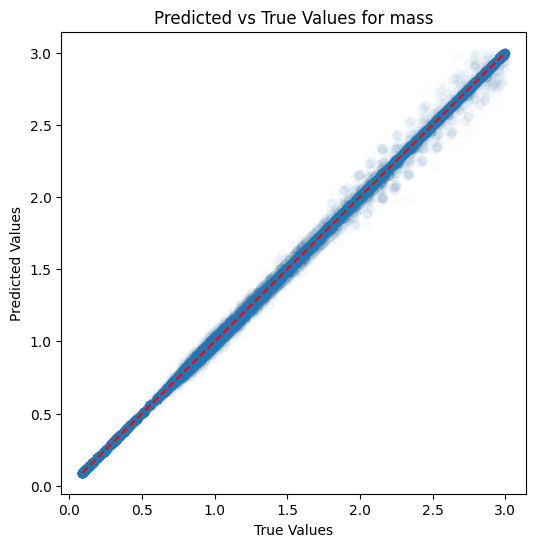

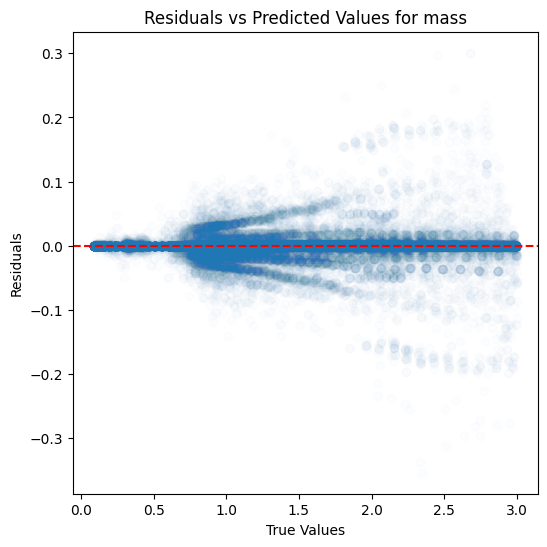

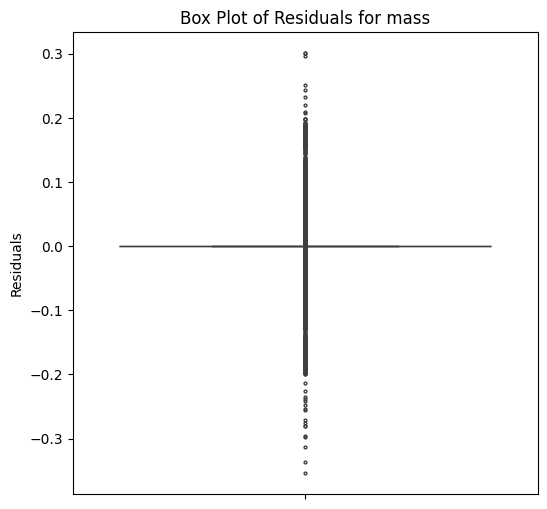

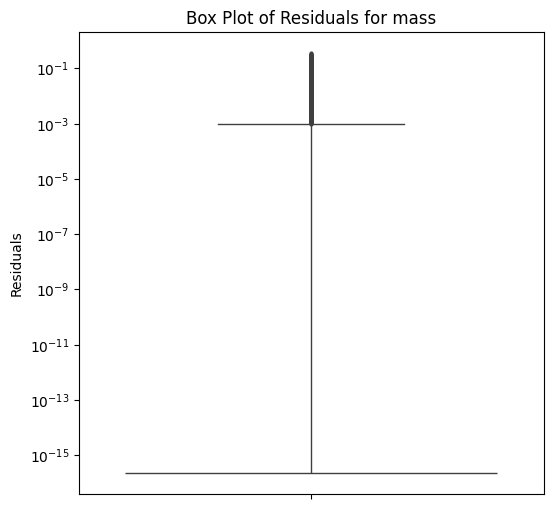

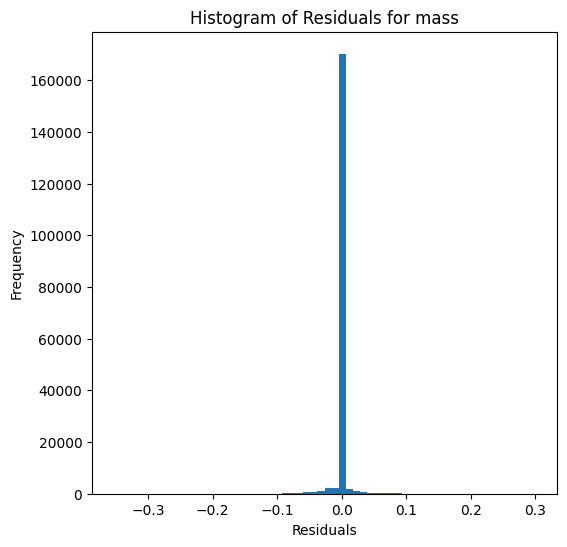

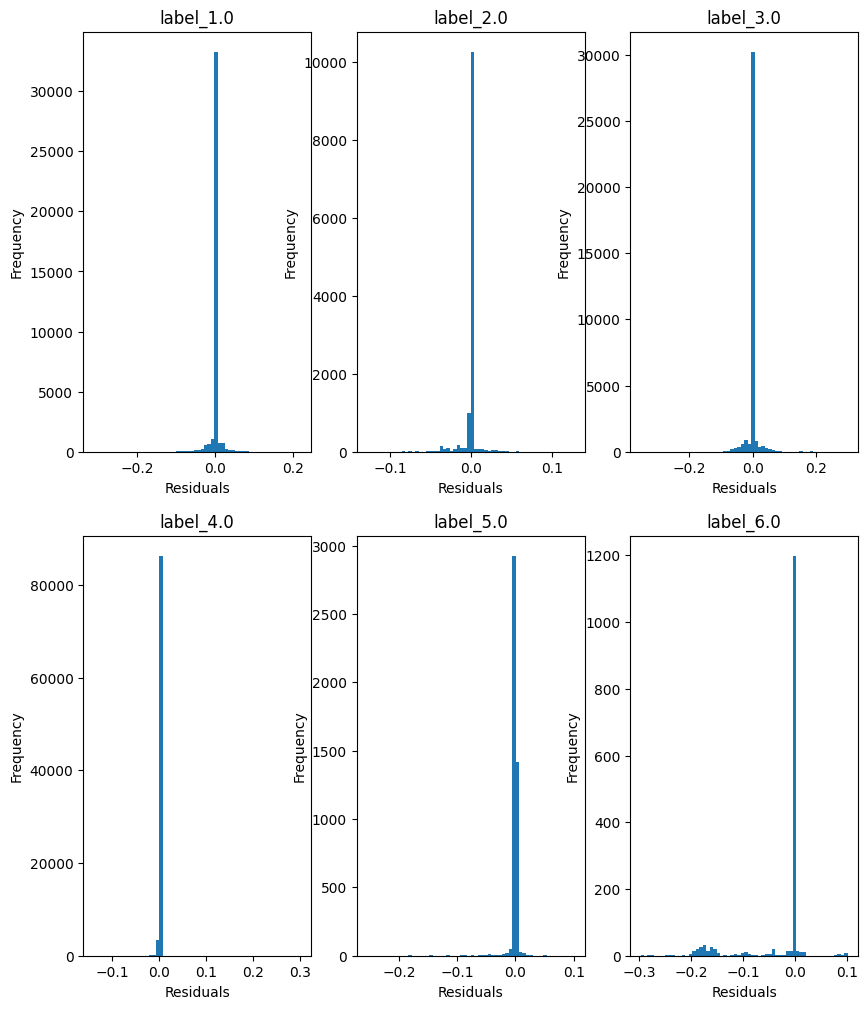

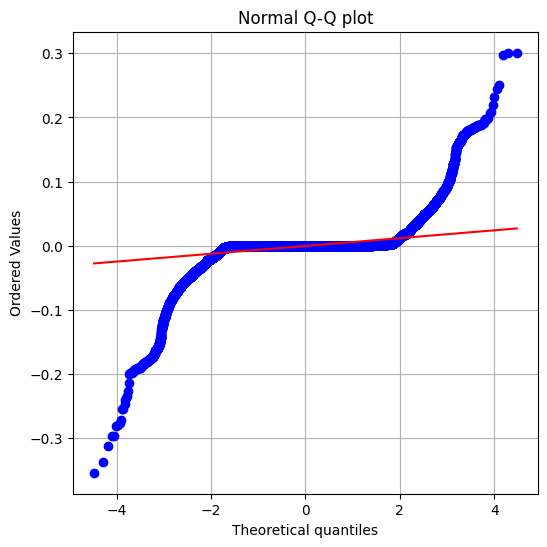

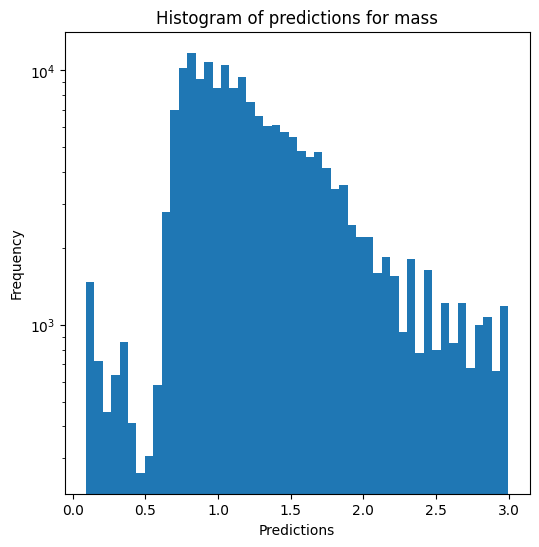

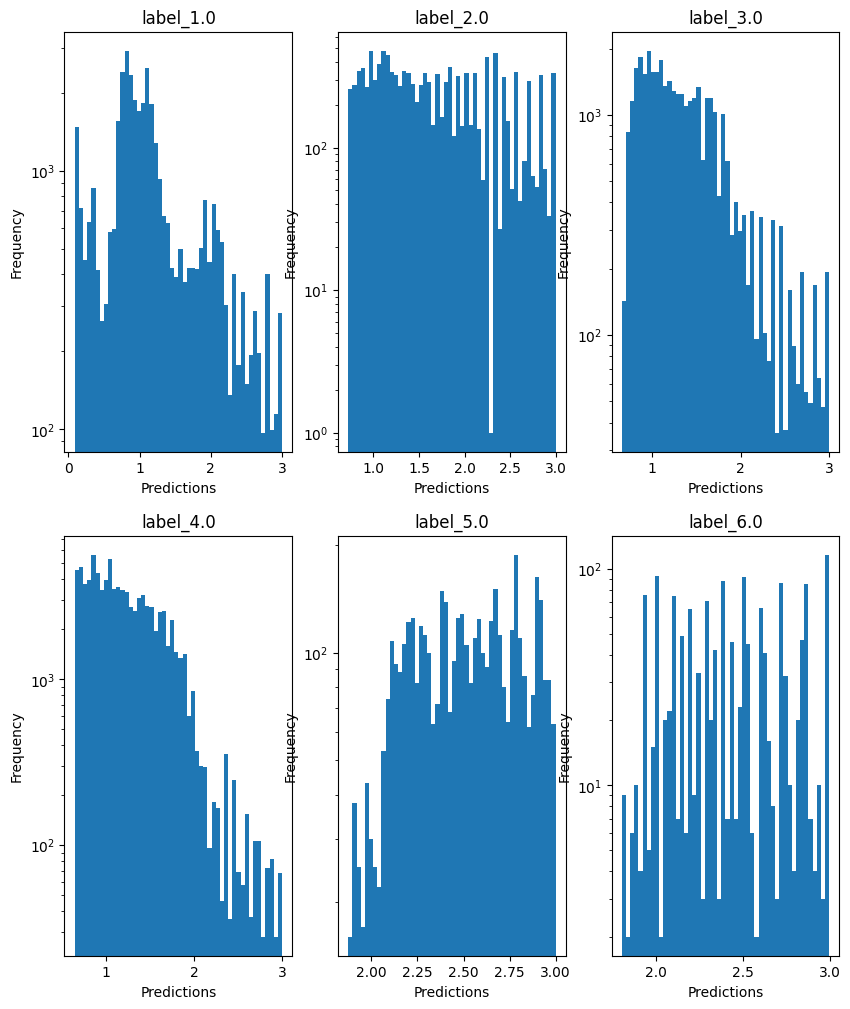

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 0.7228806106869394
  RVE :  0.9997433559877703
  RMSE :  0.004813472245302639
  MAE :  0.0017573481231242622
  MedAE :  2.7755575615628914e-17
  CORR :  0.9998716719772635
  MAX_ER :  0.08593267655840048
  Percentiles : 
    75th percentile :  0.001232630517191996
    90th percentile :  0.005315588170086025
    95th percentile :  0.009694355590399436
    99th percentile :  0.02190241020104512

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 1.2289134059946882
  RVE :  0.999186317135907
  RMSE :  0.006964643988089452
  MAE :  0.0030811464517872277
  MedAE :  0.0
  CORR :  0.999593629829325
  MAX_ER :  0.0914021384144007
  Percentiles : 
    75th percentile :  0.003542388986433803
    90th percentile :  0.011498263394070129
    95th percentile :  0.015595414575131675
    99th percentile :  0.027130577484173378

radius results for the label cate

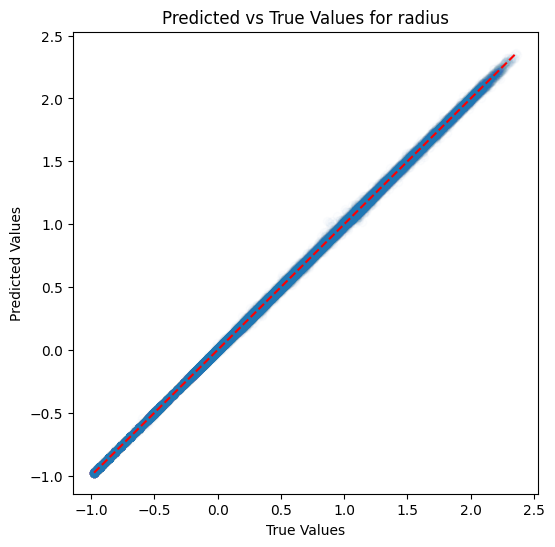

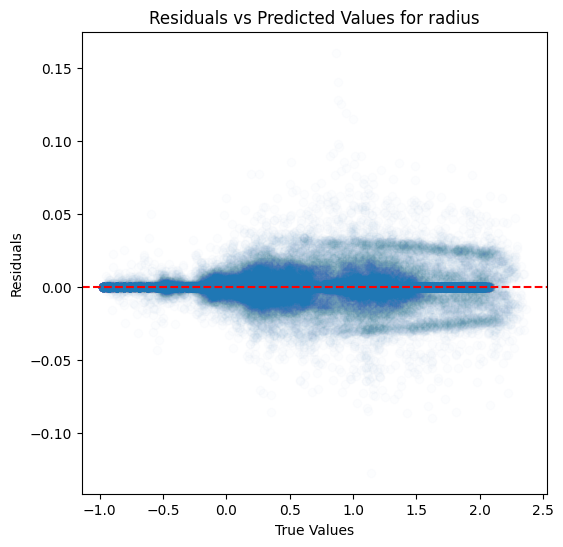

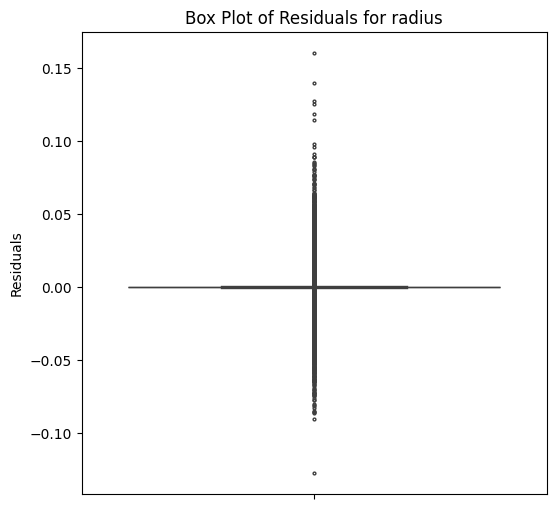

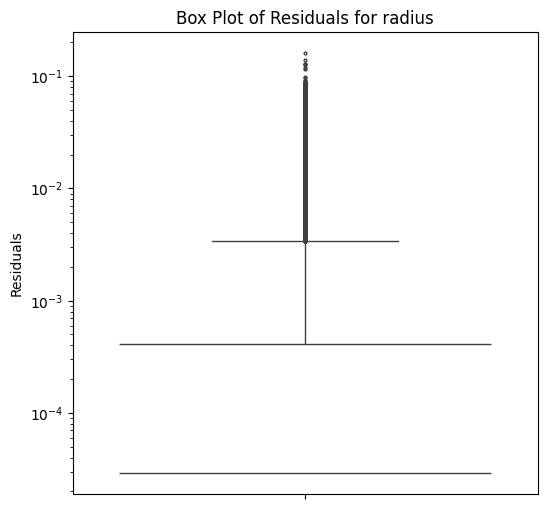

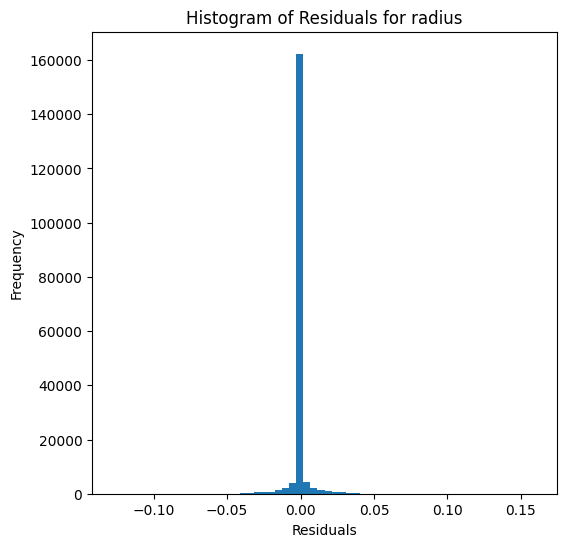

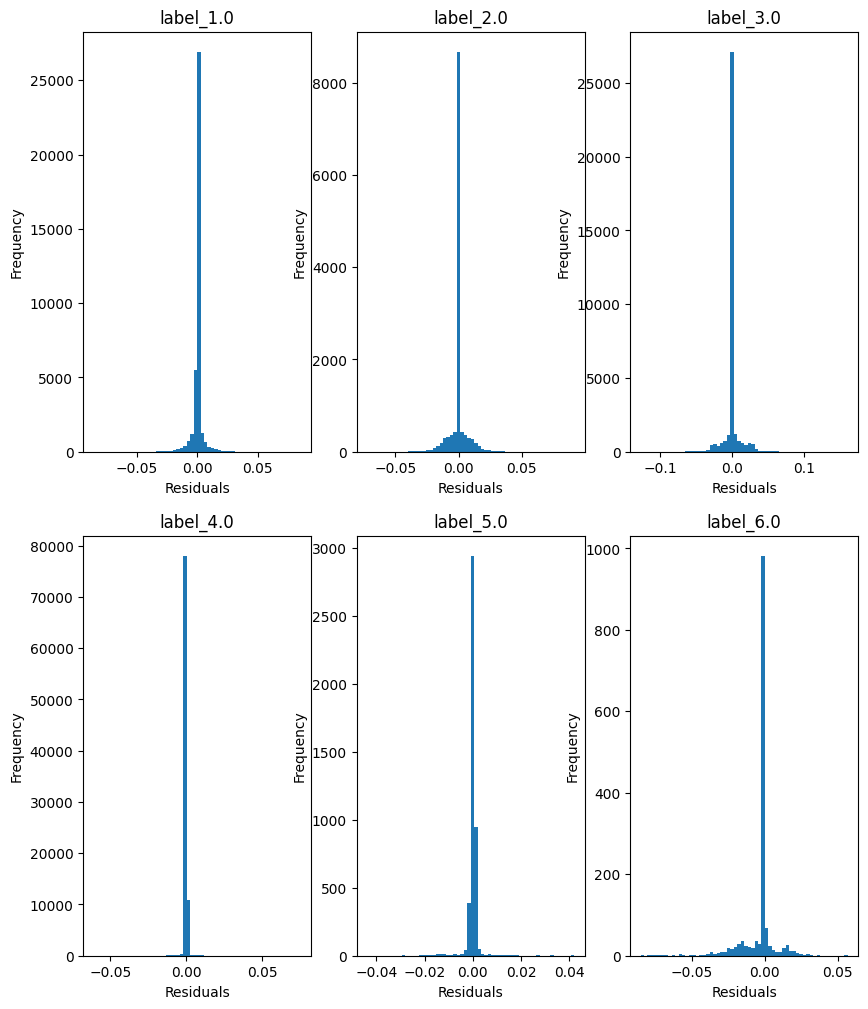

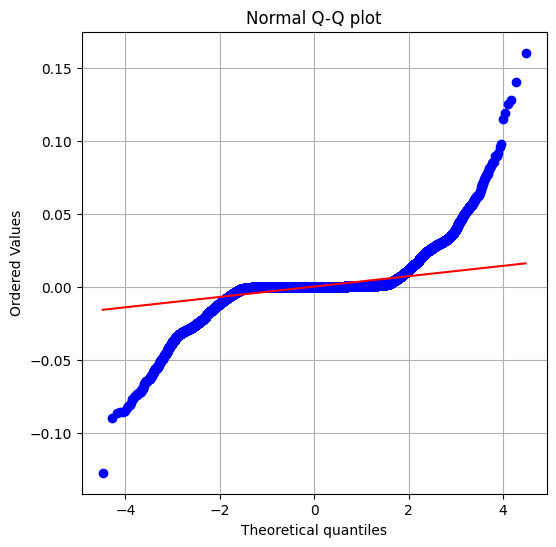

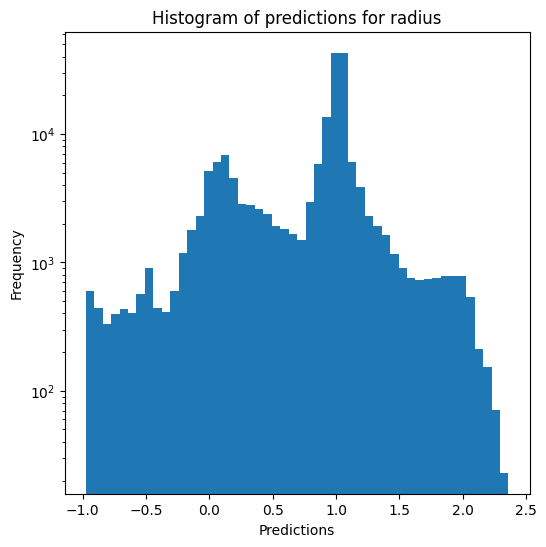

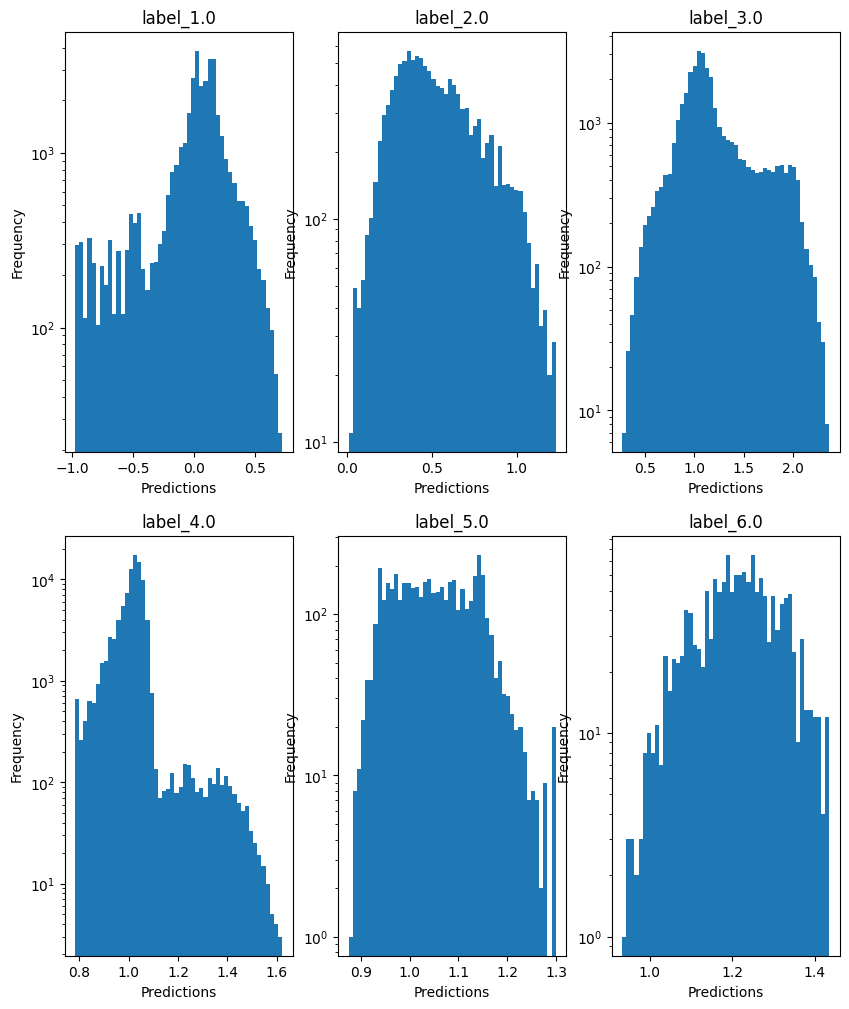

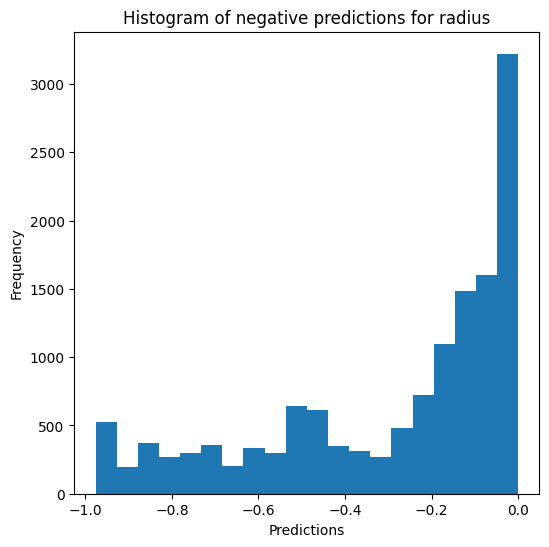

Saving predictions and results...
True
True
True
True


In [ ]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show) #, override=False, use_preds=True)

### K-nearest neighbours

In [14]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


no negative values

mass results for the label category with a value of 1.0
  value range :  0.09 - 2.999
  RVE :  0.9975156675436833
  RMSE :  0.03200672224450317
  MAE :  0.014979059851281788
  MedAE :  0.0050000000000001155
  CORR :  0.9987703679142015
  MAX_ER :  0.6562000000000001
  Percentiles : 
    75th percentile :  0.016599999999999948
    90th percentile :  0.03960000000000007
    95th percentile :  0.06400000000000006
    99th percentile :  0.1372

mass results for the label category with a value of 2.0
  value range :  0.726 - 2.996
  RVE :  0.9990663179816773
  RMSE :  0.019450754397847075
  MAE :  0.0109082428115016
  MedAE :  0.005799999999999805
  CORR :  0.9995595096150178
  MAX_ER :  0.19419999999999993
  Percentiles : 
    75th percentile :  0.015200000000000102
    90th percentile :  0.0259999999999998
    95th percentile :  0.04259999999999975
    99th percentile :  0.08500000000000033

mass results for the label category with a value of 3.0
  value range :  0.655

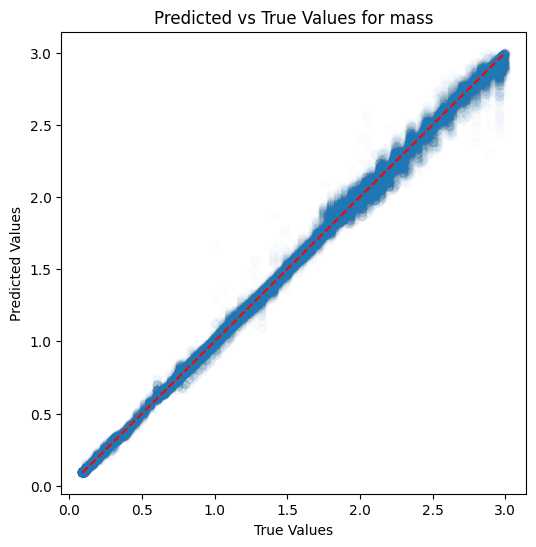

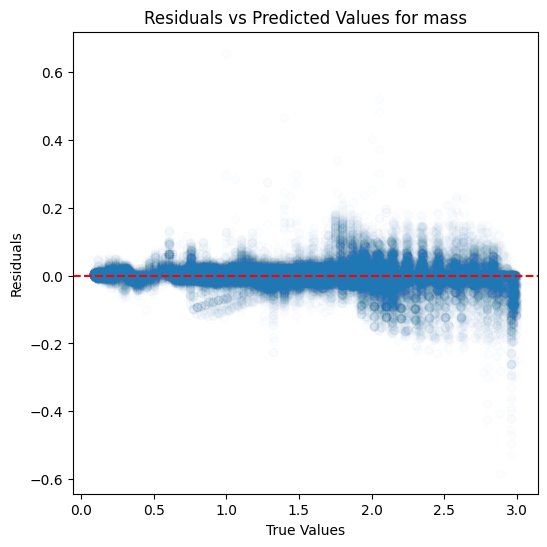

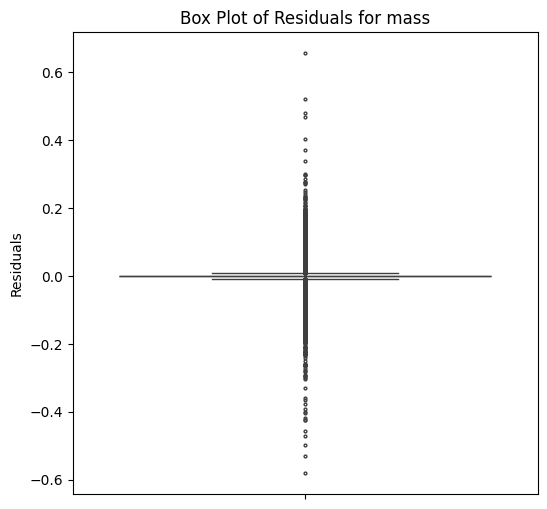

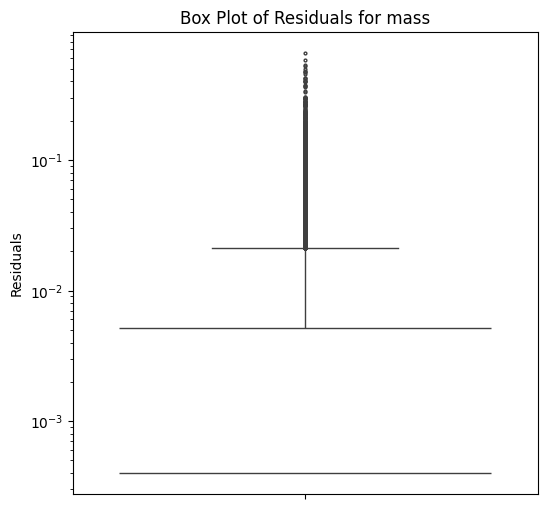

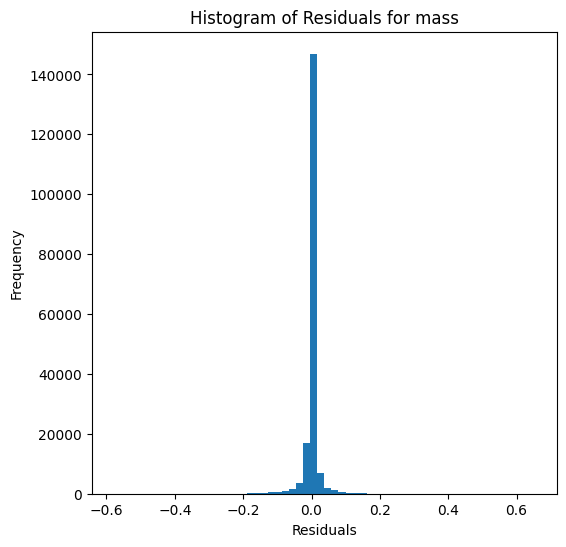

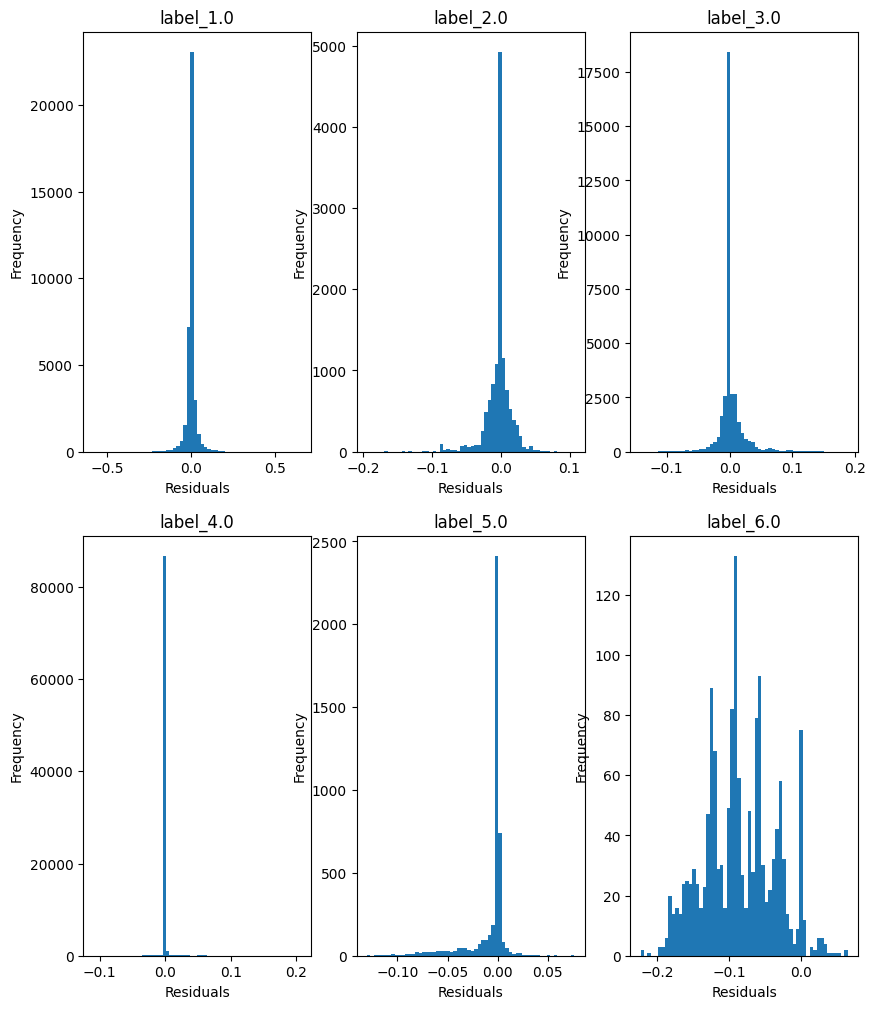

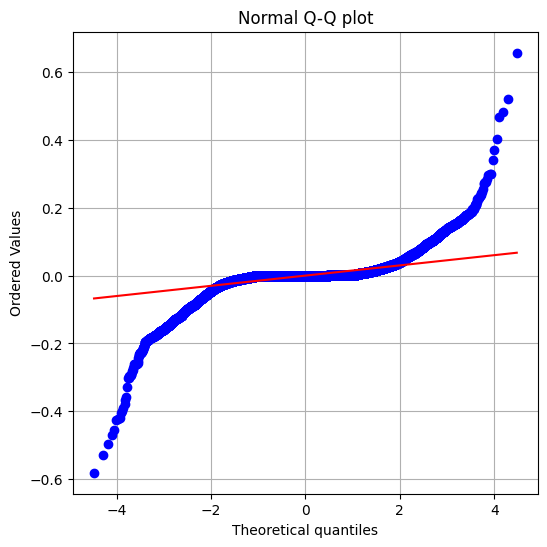

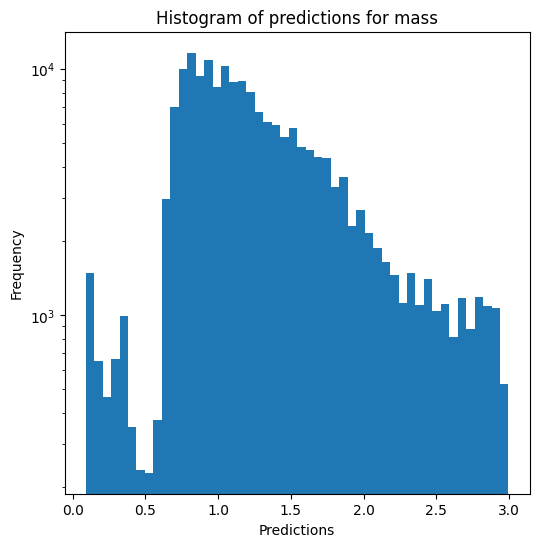

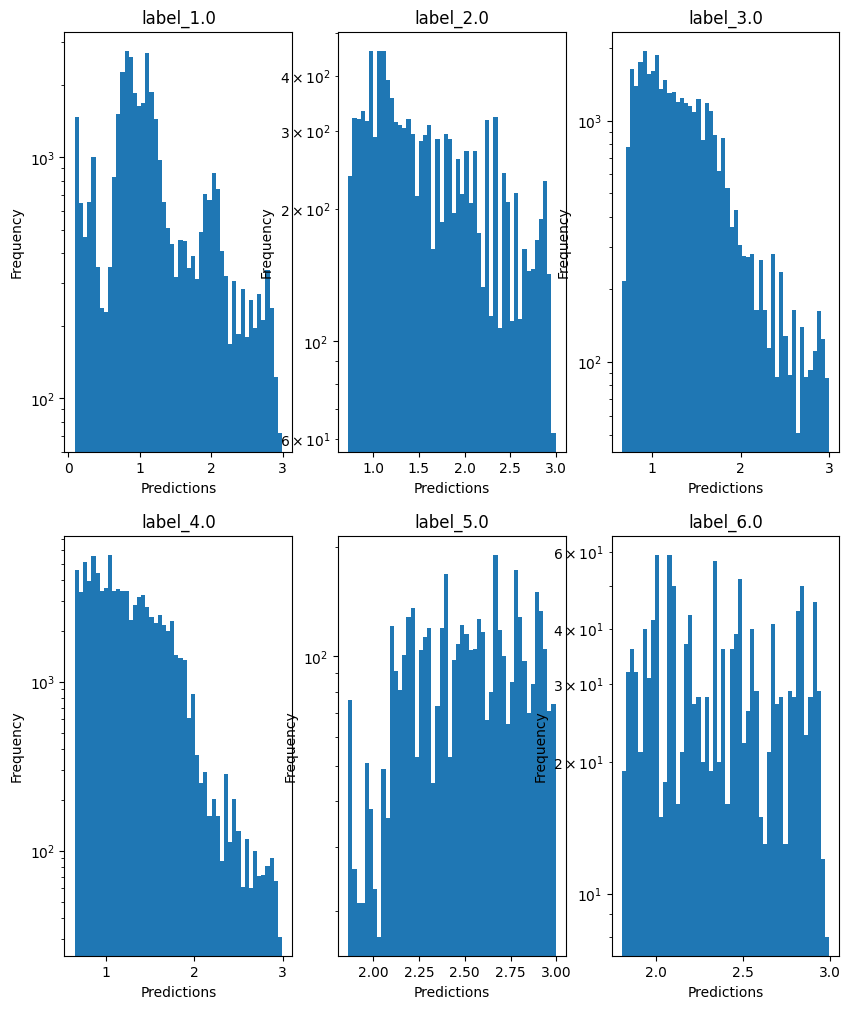


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 0.7228806106869394
  RVE :  0.9989234178730453
  RMSE :  0.00987641772869747
  MAE :  0.005876040131809627
  MedAE :  0.0030877327859323567
  CORR :  0.9994648580144369
  MAX_ER :  0.1207677416985975
  Percentiles : 
    75th percentile :  0.008041893721954504
    90th percentile :  0.014876333842642517
    95th percentile :  0.020652963052801624
    99th percentile :  0.03801605017778926

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 1.2289134059946882
  RVE :  0.9993918667573749
  RMSE :  0.006038228885699132
  MAE :  0.004592917039803602
  MedAE :  0.0035874018473111002
  CORR :  0.999696946169518
  MAX_ER :  0.03184811260315412
  Percentiles : 
    75th percentile :  0.006373888007864717
    90th percentile :  0.009730958695125403
    95th percentile :  0.01214272656044561
    99th percentile :  0.018096016645276134

radius results for 

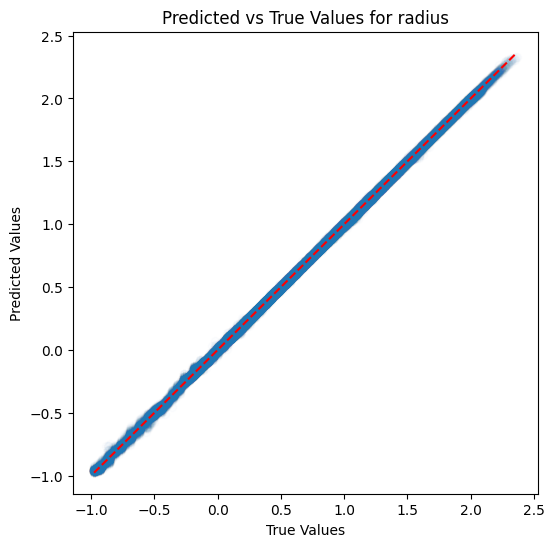

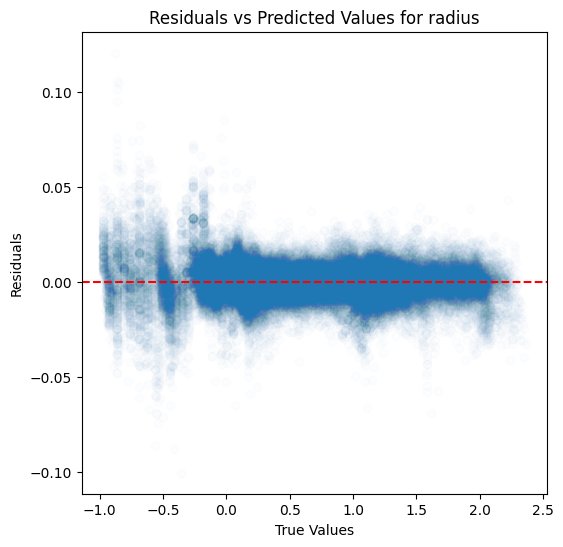

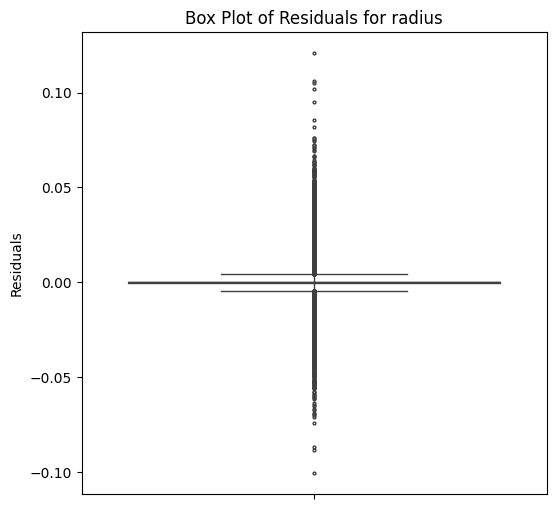

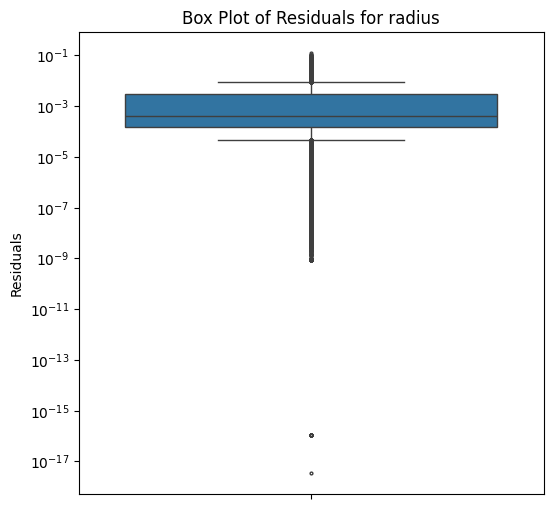

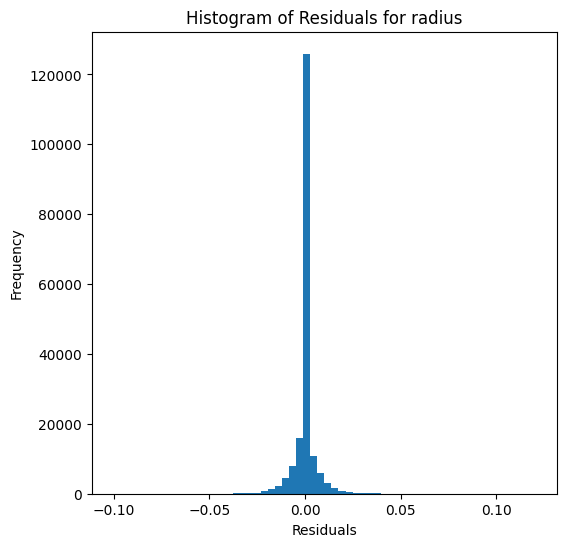

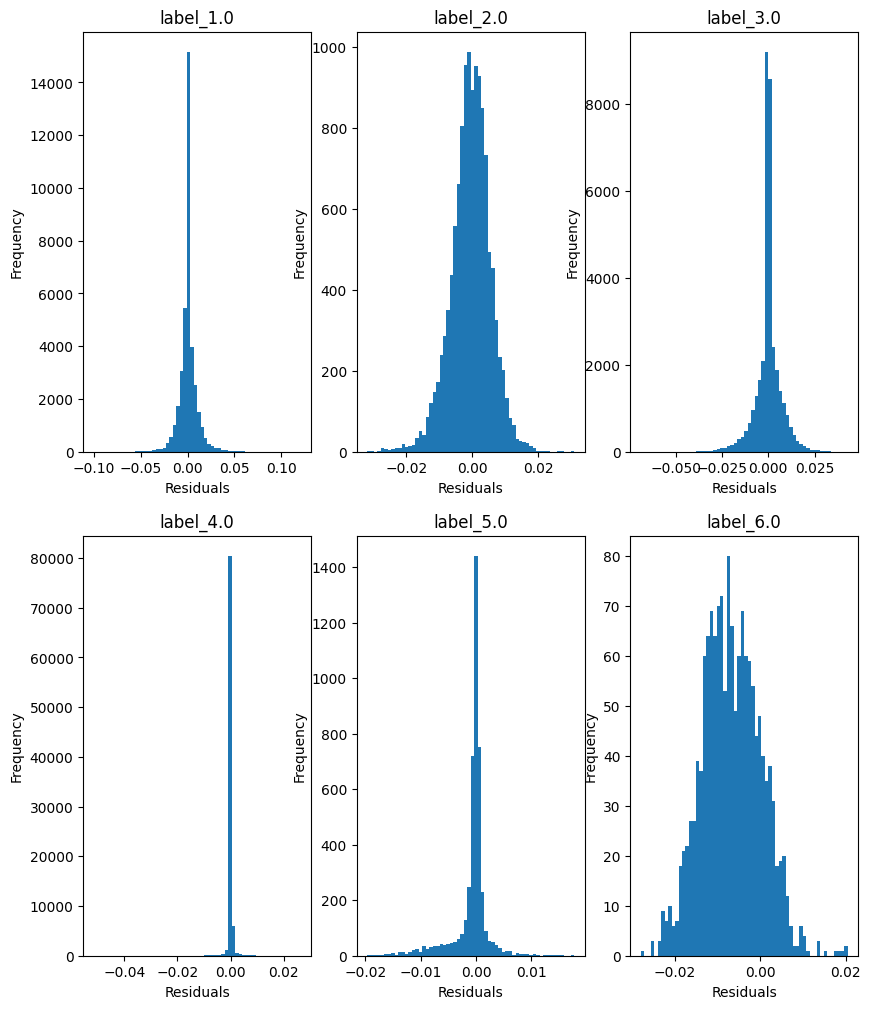

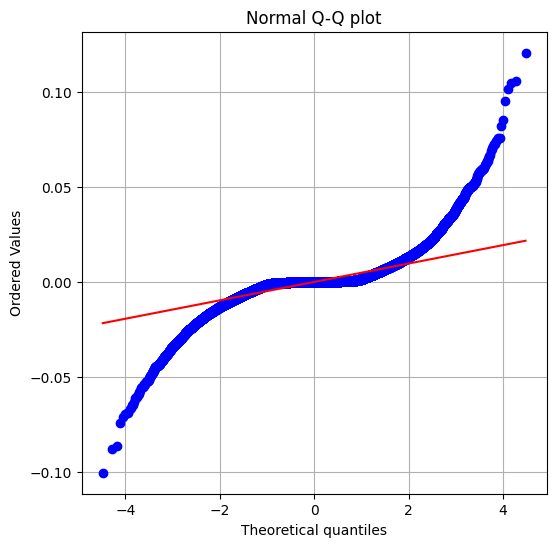

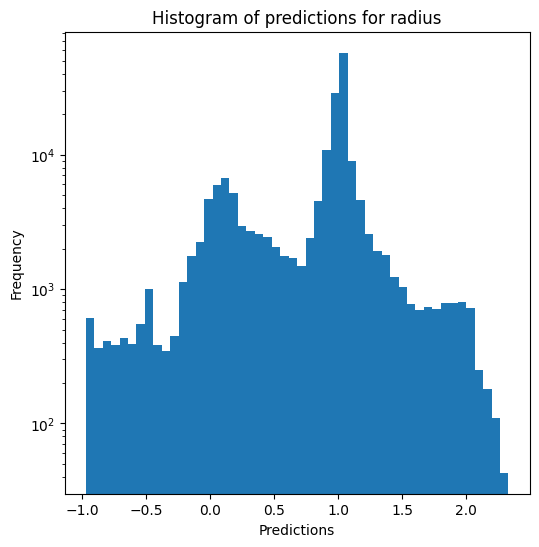

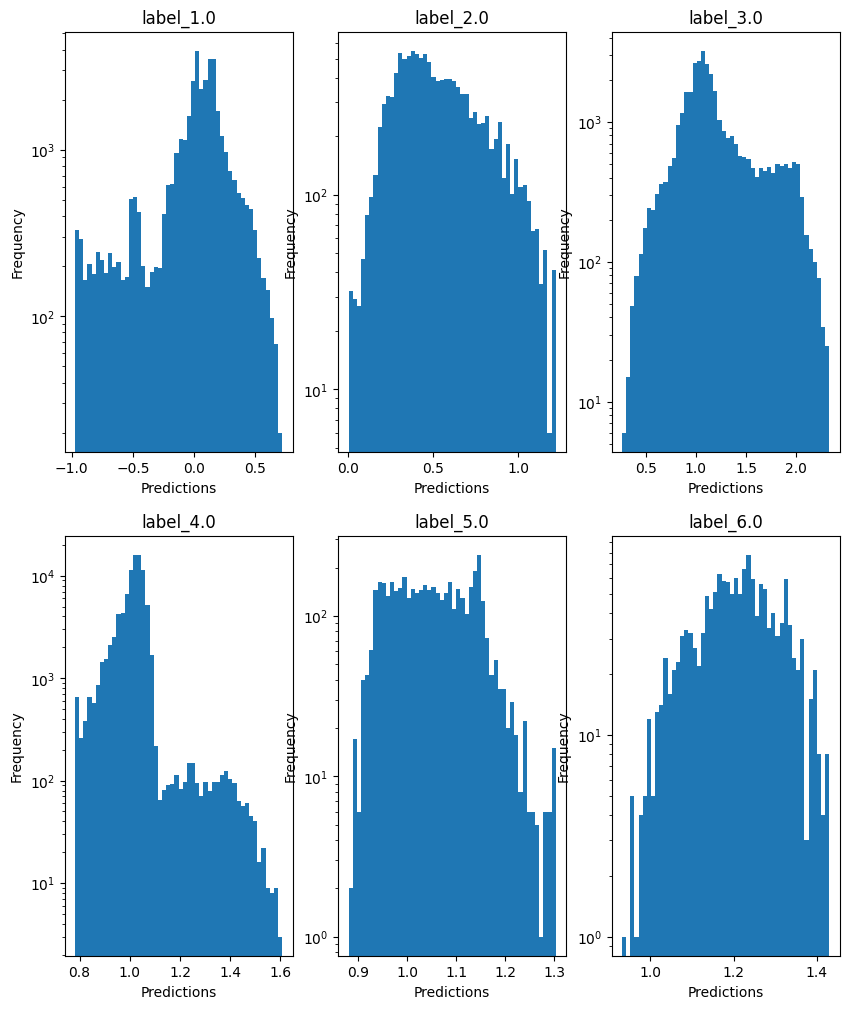

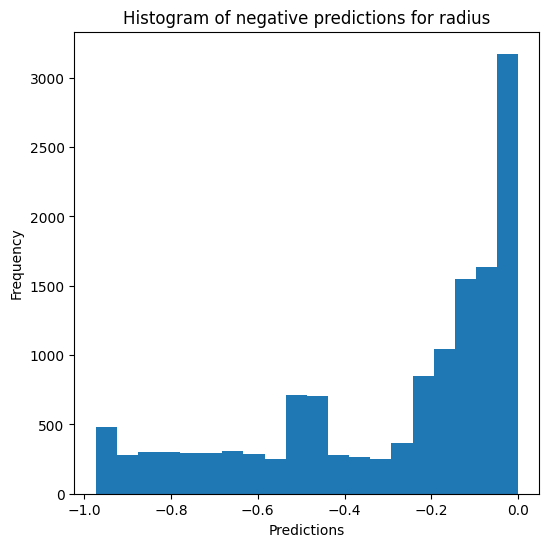

Saving predictions and results...
True
True
True
True


In [ ]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show)

### Random forests

In [16]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the label category with a value of 1.0
  value range :  0.09 - 2.999
  RVE :  0.9998752417991507
  RMSE :  0.007178831032769633
  MAE :  0.002345166030215883
  MedAE :  0.00012999999999940837
  CORR :  0.999937968724471
  MAX_ER :  0.15781000000000134
  Percentiles : 
    75th percentile :  0.0011599999999981347
    90th percentile :  0.006729999999999259
    95th percentile :  0.012890000000000823
    99th percentile :  0.032207800000000134

mass results for the label category with a value of 2.0
  value range :  0.726 - 2.996
  RVE :  0.9998663184264494
  RMSE :  0.007393924444293661
  MAE :  0.0030803784478173725
  MedAE :  0.0002399999999991298
  CORR :  0.9999335195331801
  MAX_ER :  0.09384999999999843
  Percentiles : 
    75th percentile :  0.002719999999996725
    90th percentile :  0.010239999999999649
    95th percentile :  0.01650049999

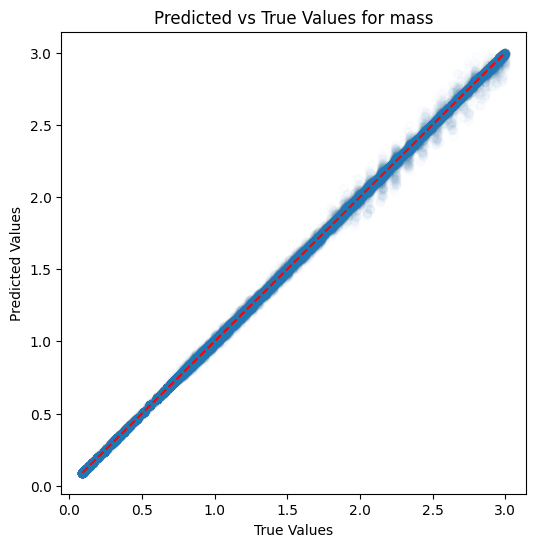

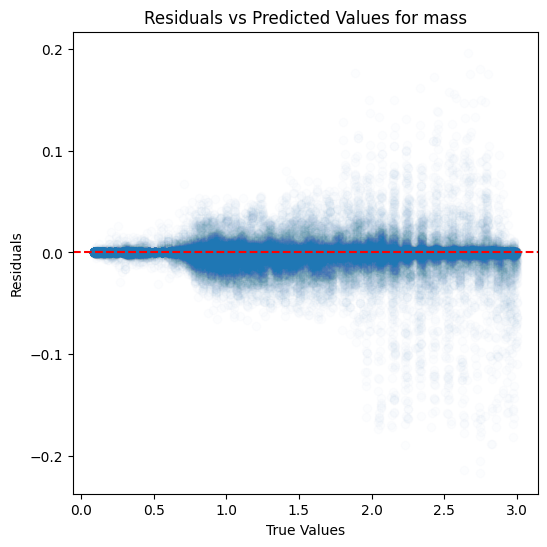

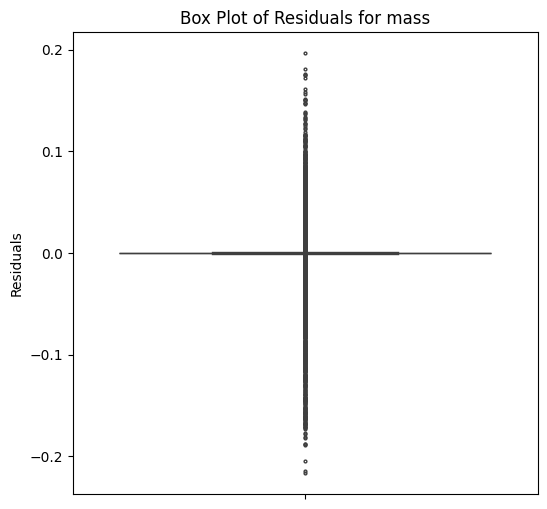

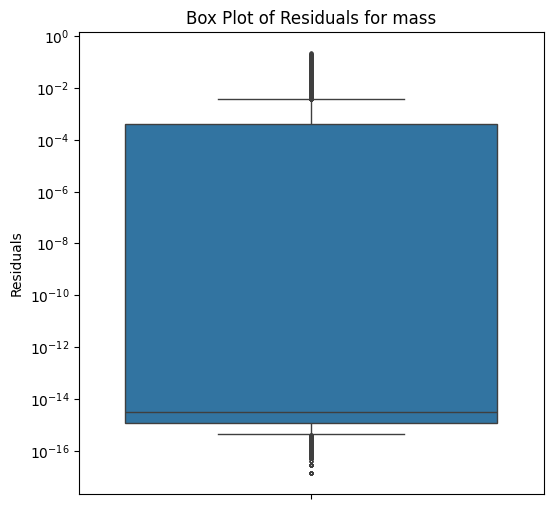

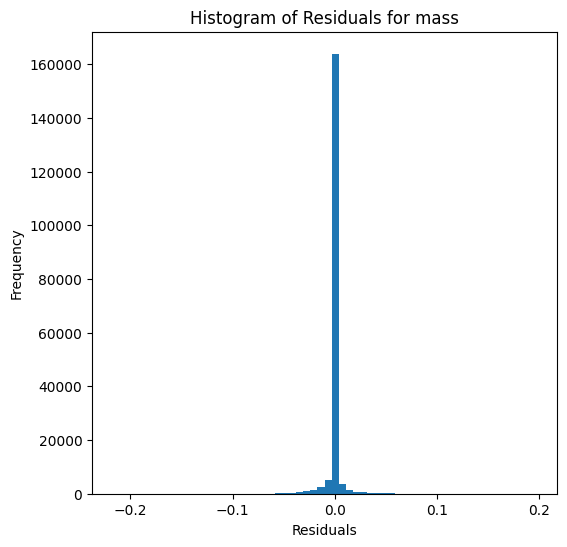

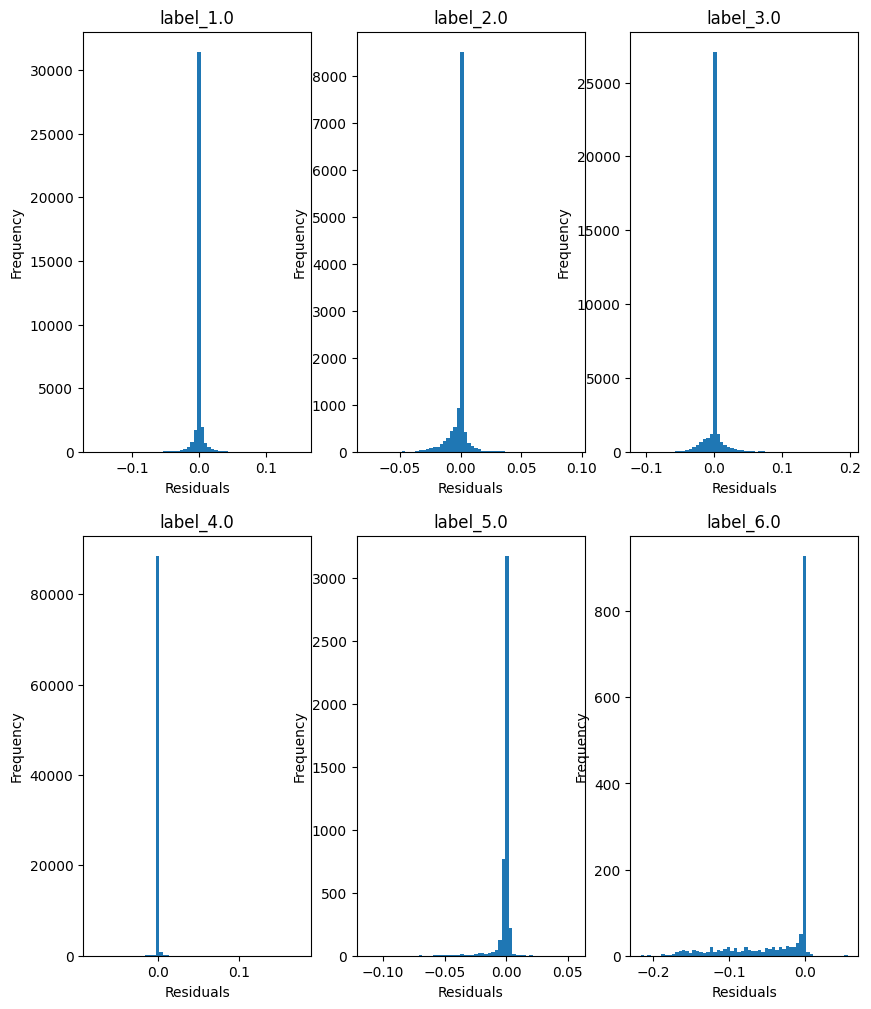

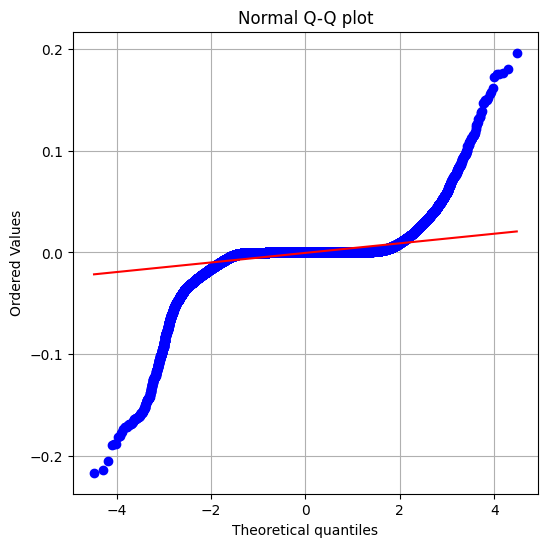

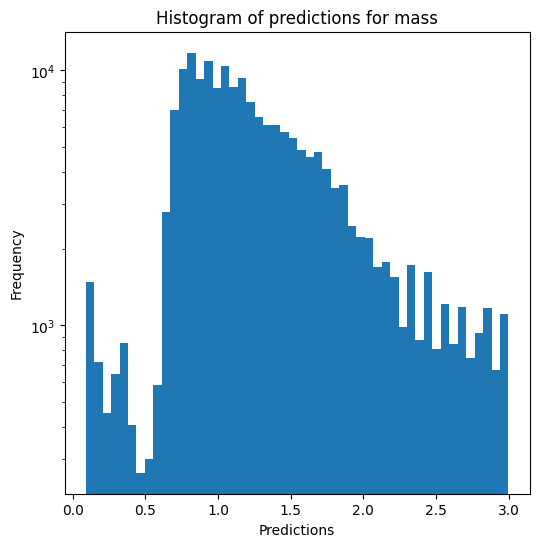

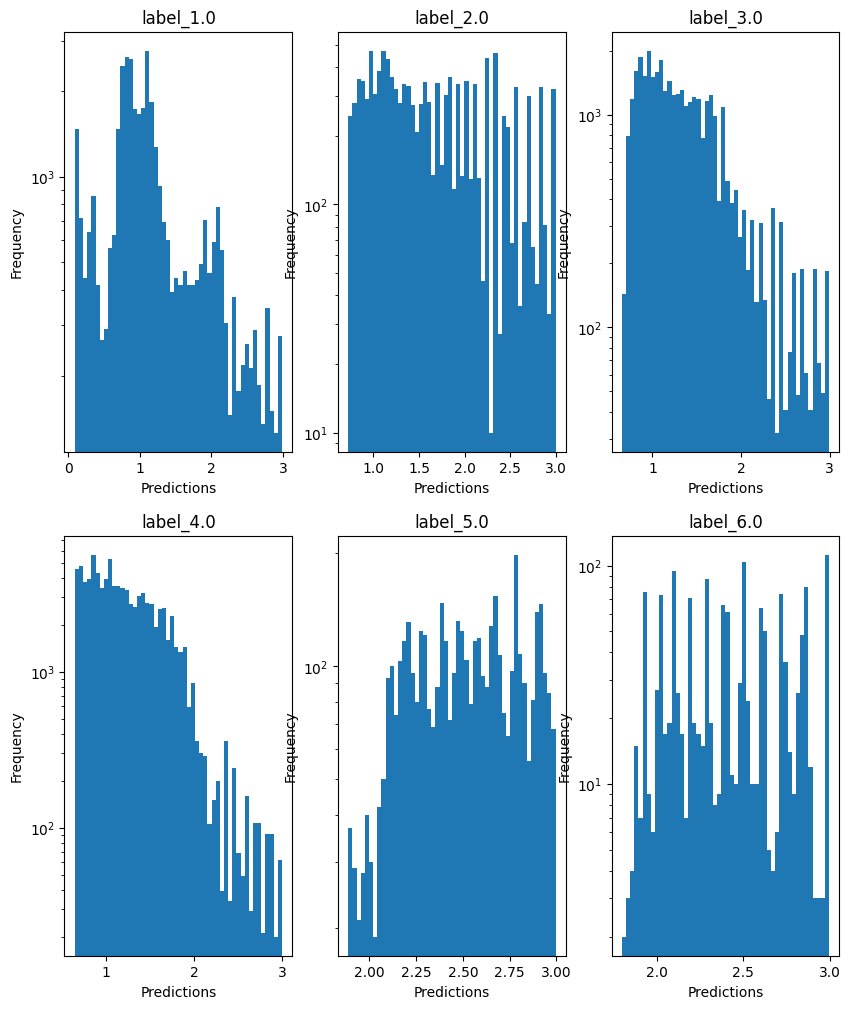


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 0.7228806106869394
  RVE :  0.999942082752317
  RMSE :  0.0022870746186966022
  MAE :  0.0009144699513593369
  MedAE :  0.00013429163094435398
  CORR :  0.9999710436775603
  MAX_ER :  0.034953438784615265
  Percentiles : 
    75th percentile :  0.0007515657639677849
    90th percentile :  0.0026791067817555792
    95th percentile :  0.004672283519254987
    99th percentile :  0.010467013208280498

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 1.2289134059946882
  RVE :  0.9998319561663607
  RMSE :  0.0031651959073117266
  MAE :  0.0014371210558810485
  MedAE :  0.0002455694836491218
  CORR :  0.9999160364095124
  MAX_ER :  0.03743111377761299
  Percentiles : 
    75th percentile :  0.001388513781759755
    90th percentile :  0.004613482097021919
    95th percentile :  0.007149641060044542
    99th percentile :  0.013079699346289626

radius 

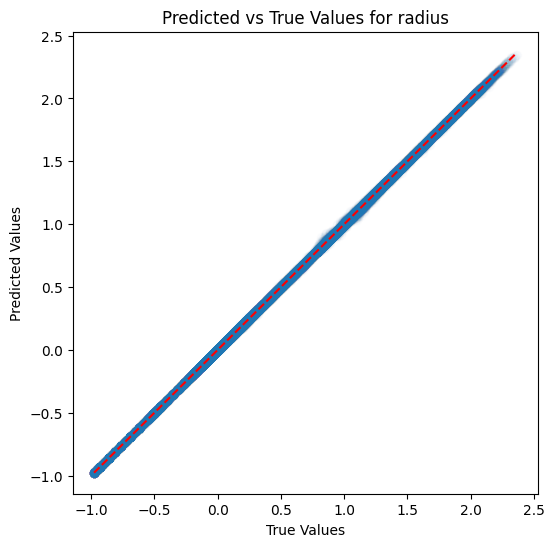

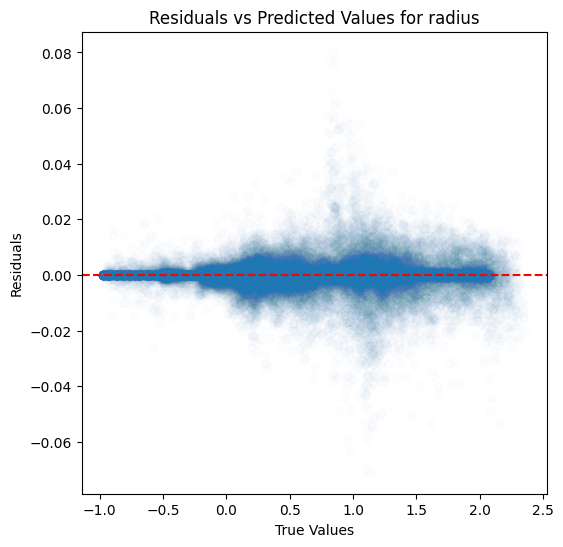

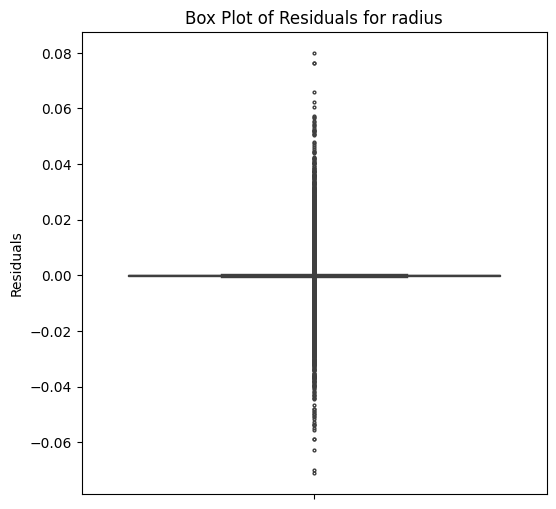

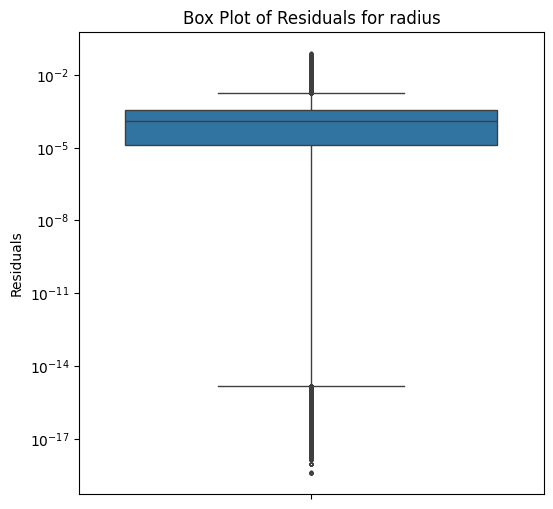

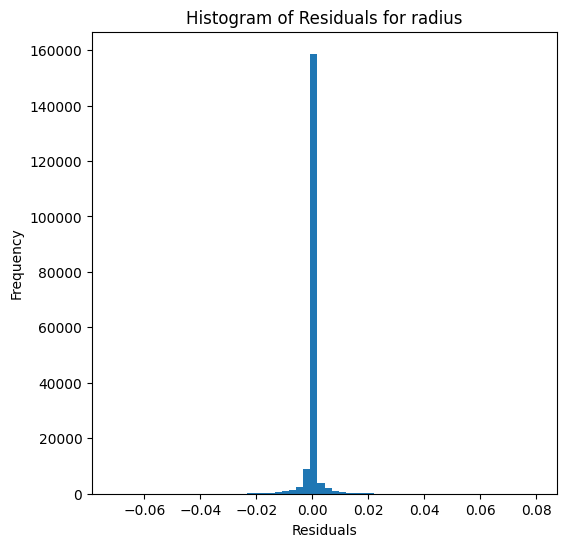

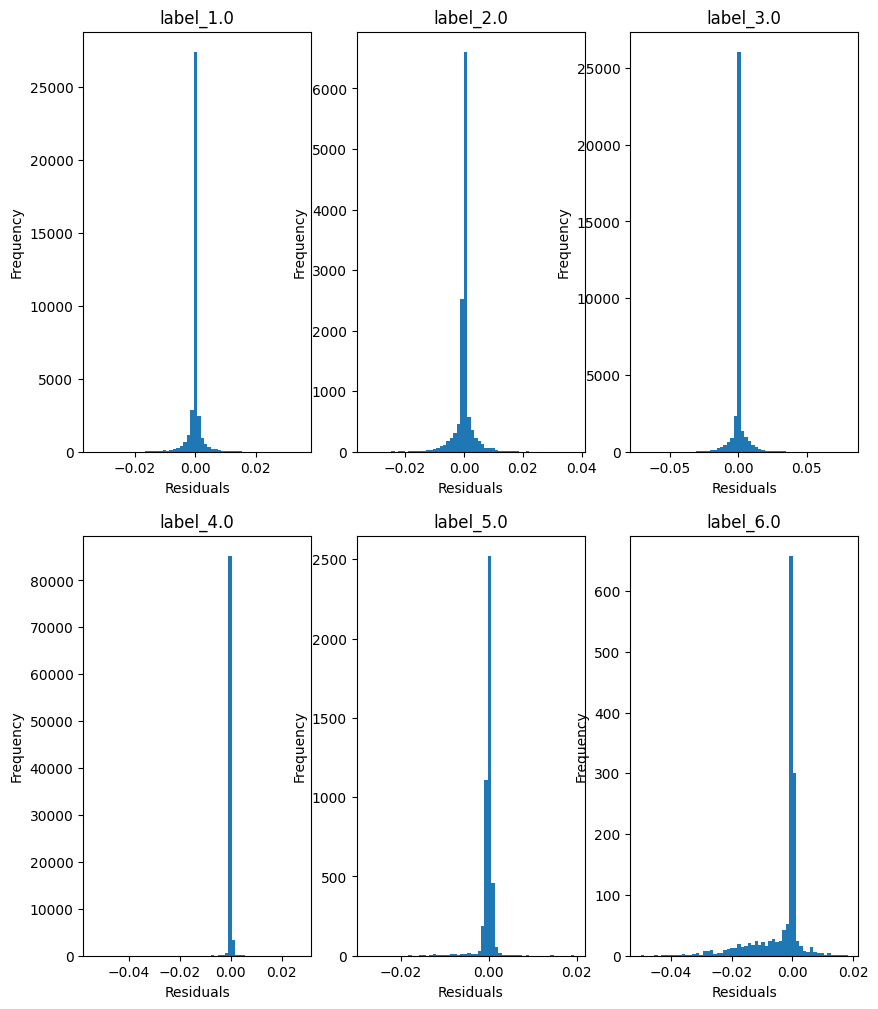

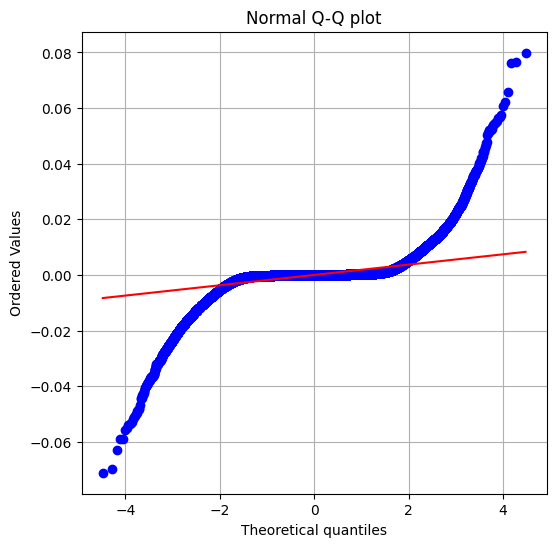

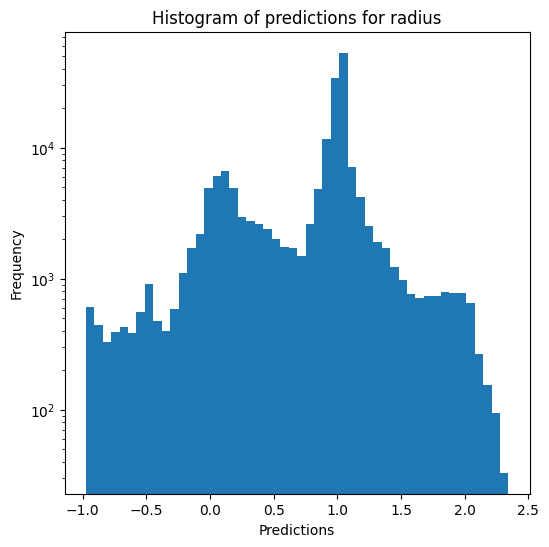

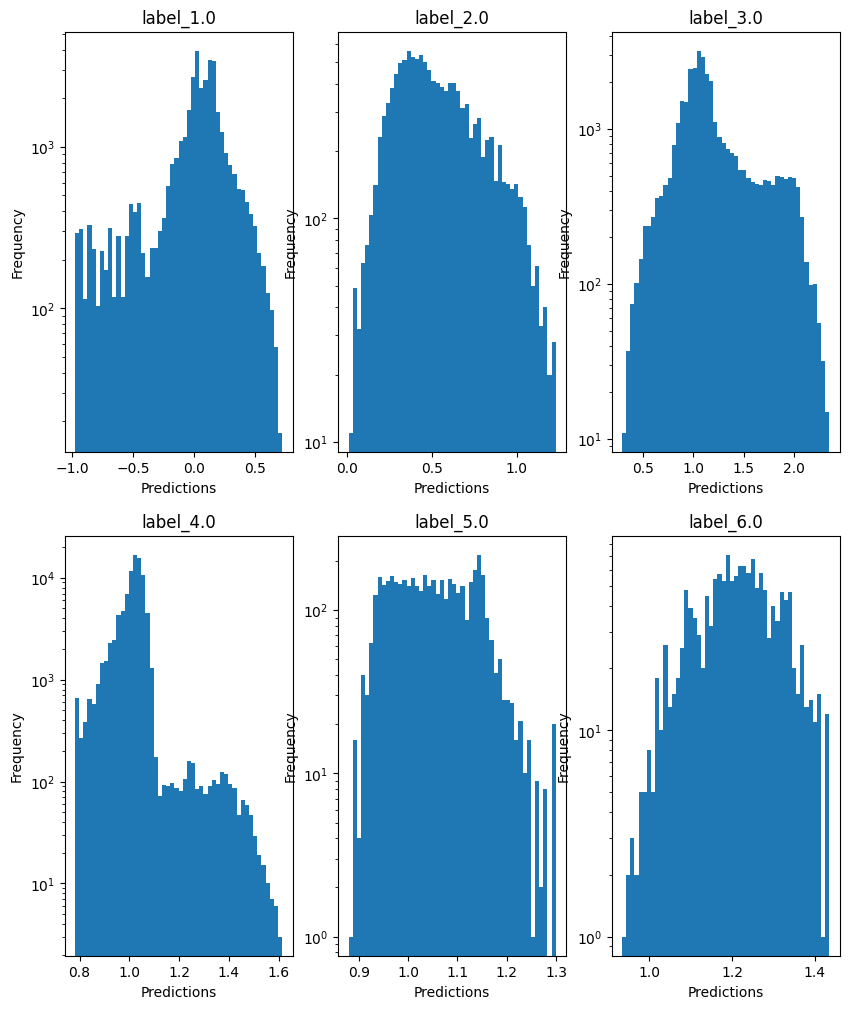

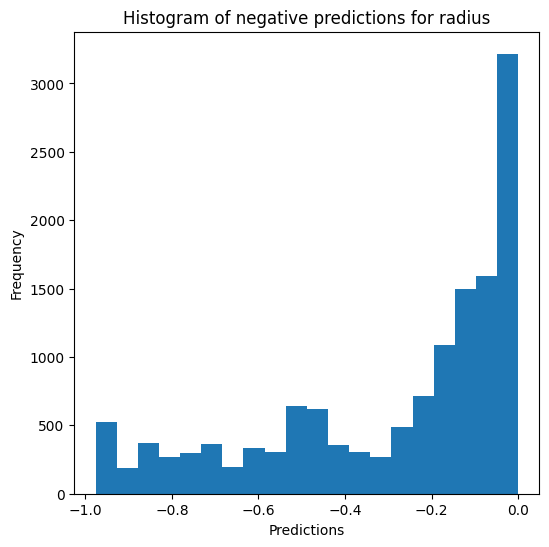

Saving predictions and results...
True
True
True
True


In [ ]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, n_jobs=5)

### XGBoost

In [18]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the label category with a value of 1.0
  value range :  0.09 - 2.999
  RVE :  0.9989190774264869
  RMSE :  0.021113900039454164
  MAE :  0.012955817968592393
  MedAE :  0.007141310691833547
  CORR :  0.999460435153906
  MAX_ER :  0.23273415374755846
  Percentiles : 
    75th percentile :  0.016863574266433867
    90th percentile :  0.03170178642272957
    95th percentile :  0.04397313084602348
    99th percentile :  0.08148778570175157

mass results for the label category with a value of 2.0
  value range :  0.726 - 2.996
  RVE :  0.9997386147290966
  RMSE :  0.010224238799817249
  MAE :  0.006961948929617581
  MedAE :  0.0046716270446776065
  CORR :  0.9998695325352005
  MAX_ER :  0.09049644279479985
  Percentiles : 
    75th percentile :  0.008902166366577369
    90th percentile :  0.016306894302368313
    95th percentile :  0.022040017175674373

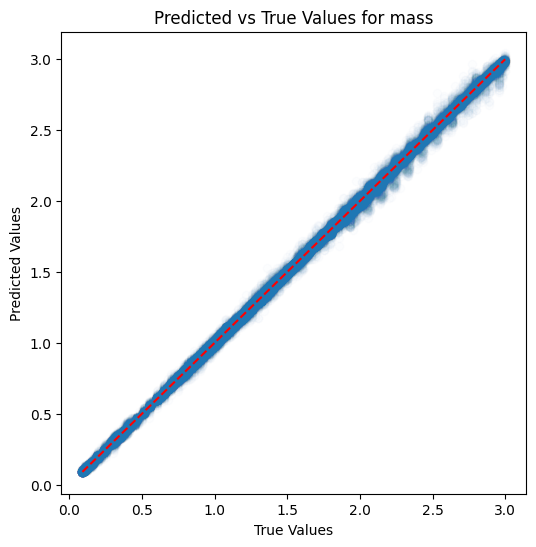

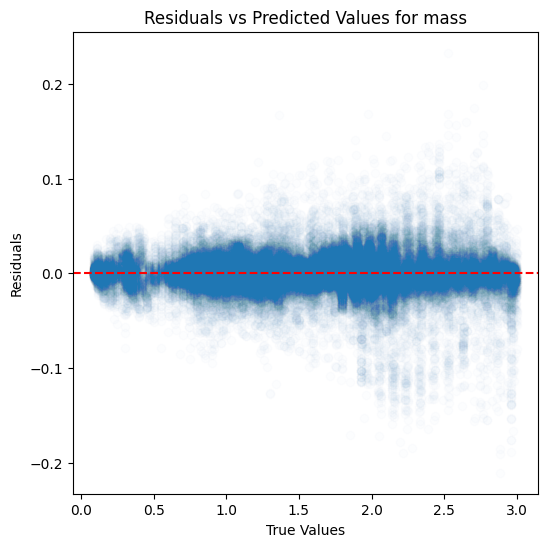

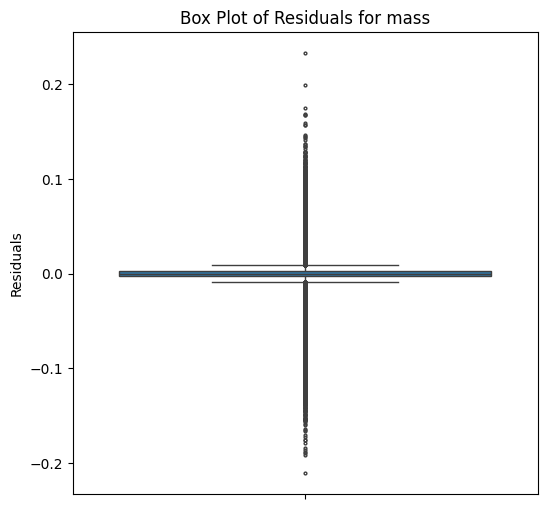

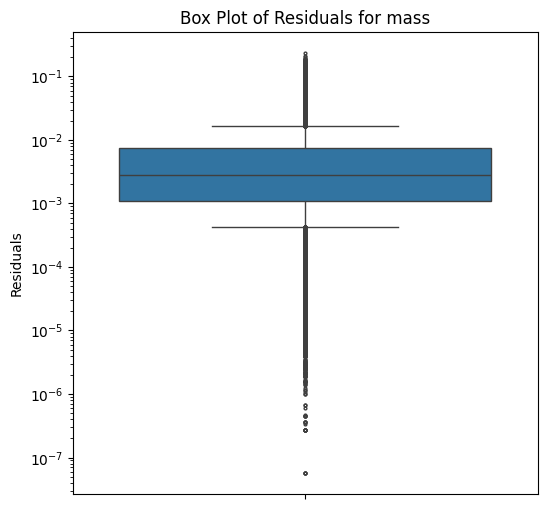

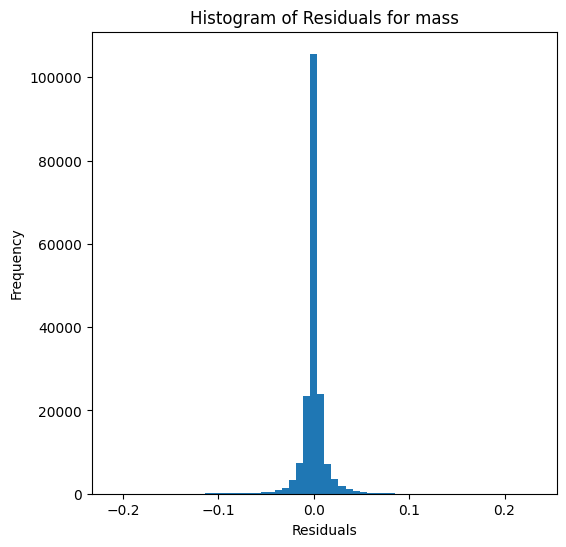

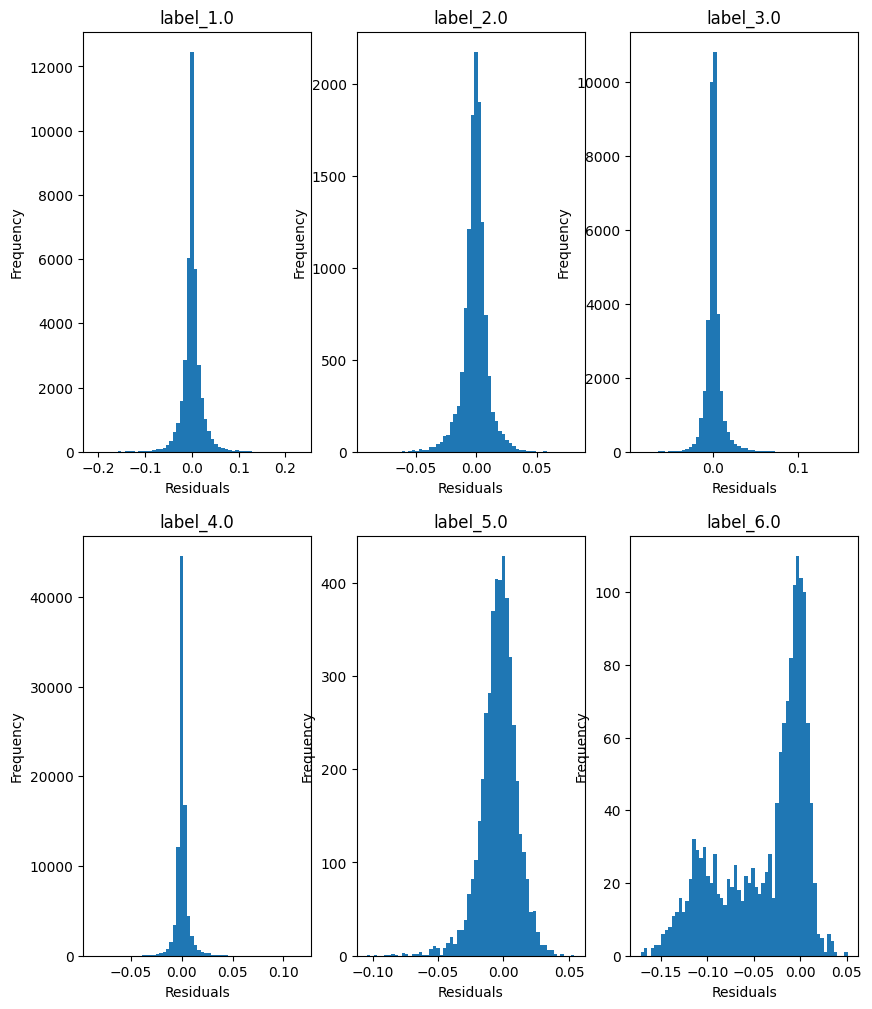

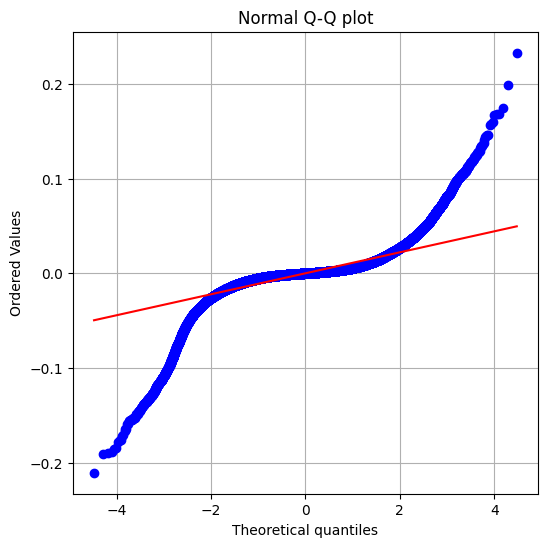

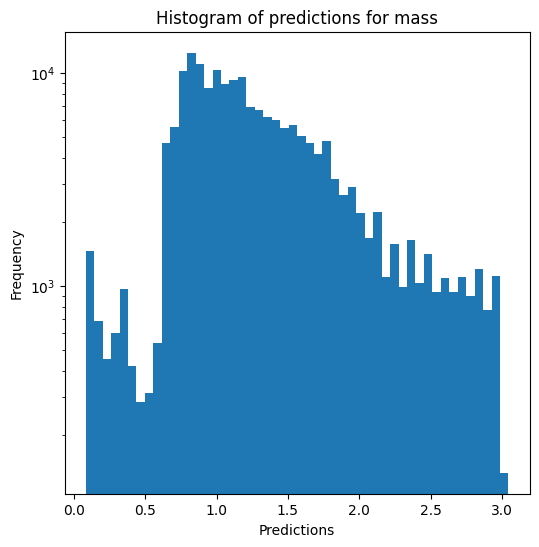

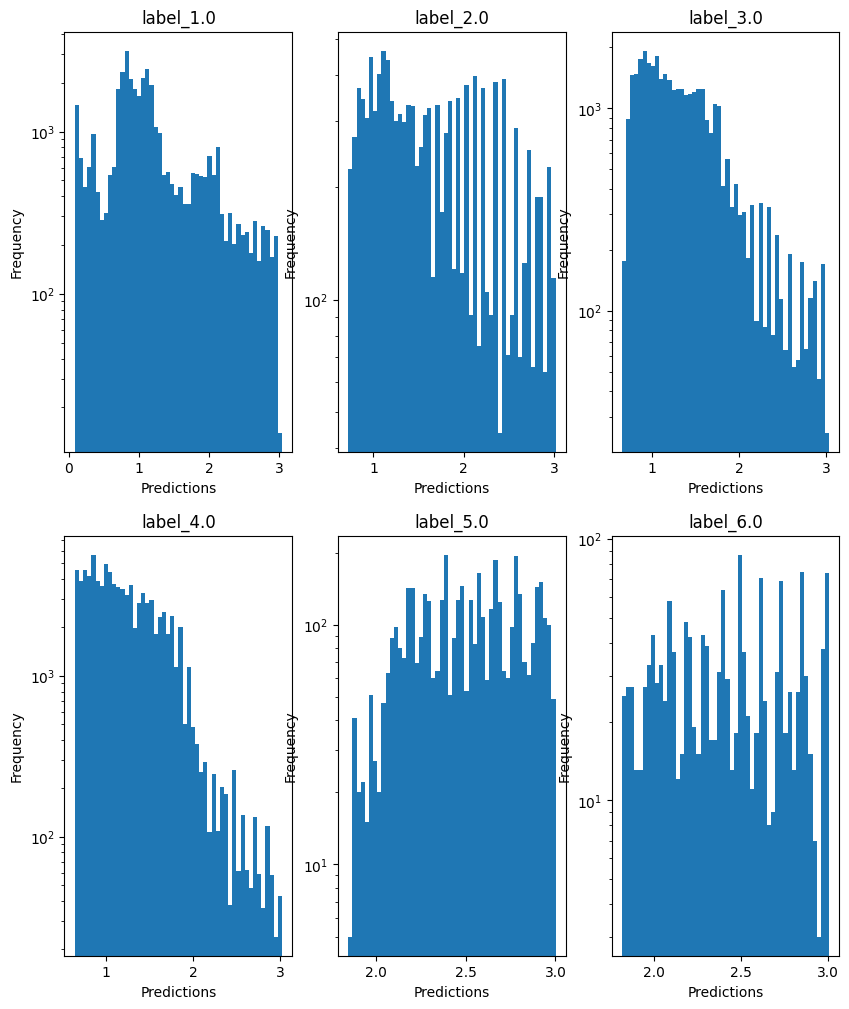


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 0.7228806106869394
  RVE :  0.9993147227108912
  RMSE :  0.00786467892100313
  MAE :  0.005198325227519067
  MedAE :  0.0034333127182981094
  CORR :  0.9996573327303526
  MAX_ER :  0.06827712710358969
  Percentiles : 
    75th percentile :  0.006730464485696034
    90th percentile :  0.01143777481045417
    95th percentile :  0.016100620052158943
    99th percentile :  0.02860042068562522

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 1.2289134059946882
  RVE :  0.9987323948124496
  RMSE :  0.008693723547433795
  MAE :  0.006917988282027232
  MedAE :  0.005892467958579839
  CORR :  0.9993660425000692
  MAX_ER :  0.040720456544565575
  Percentiles : 
    75th percentile :  0.009927378298236977
    90th percentile :  0.014242375528363705
    95th percentile :  0.016934818188078175
    99th percentile :  0.022639018099789562

radius results fo

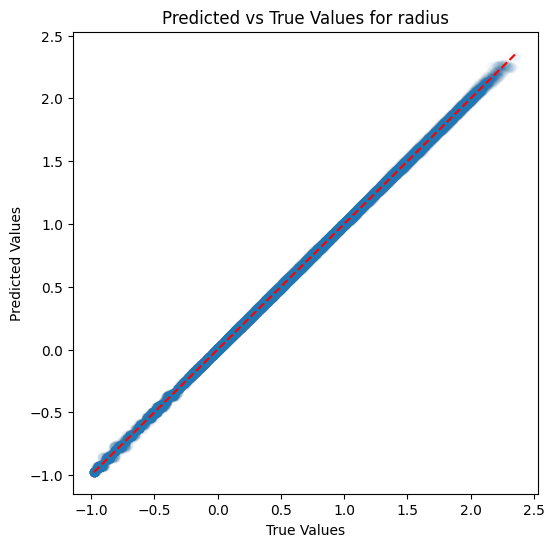

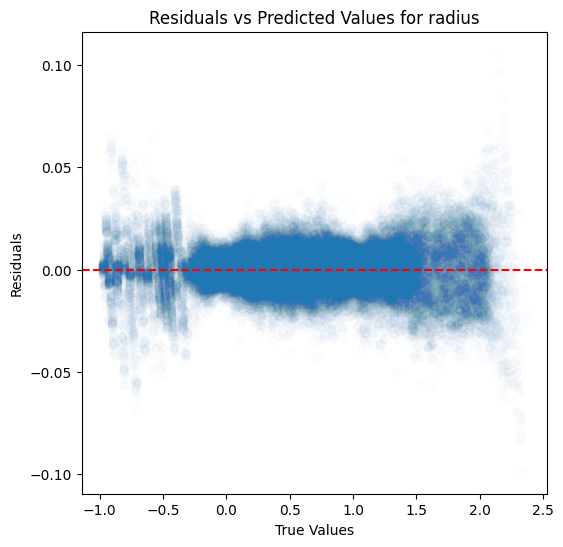

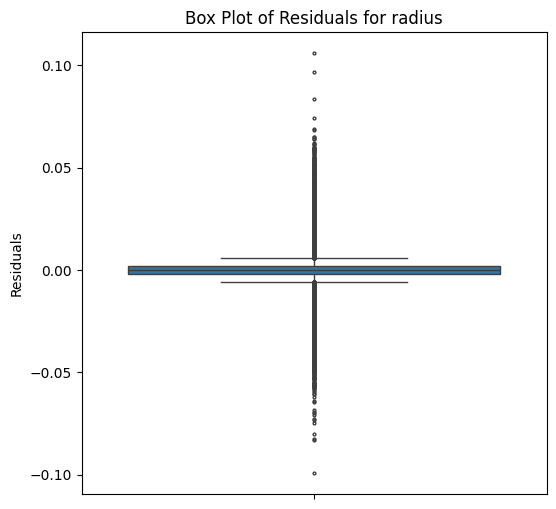

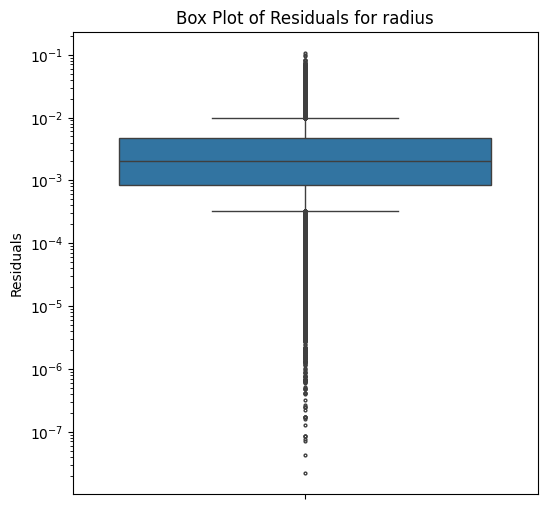

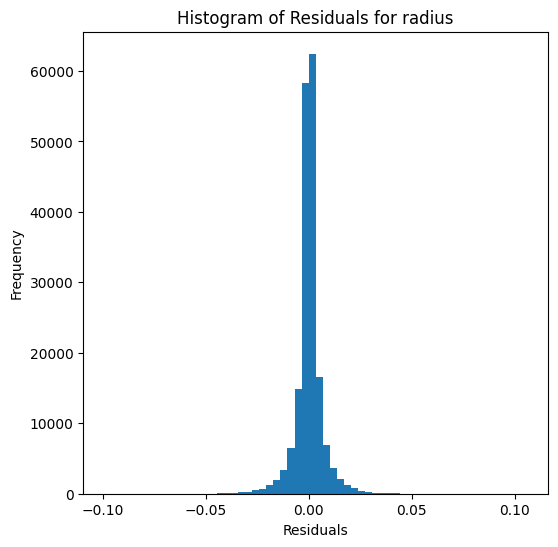

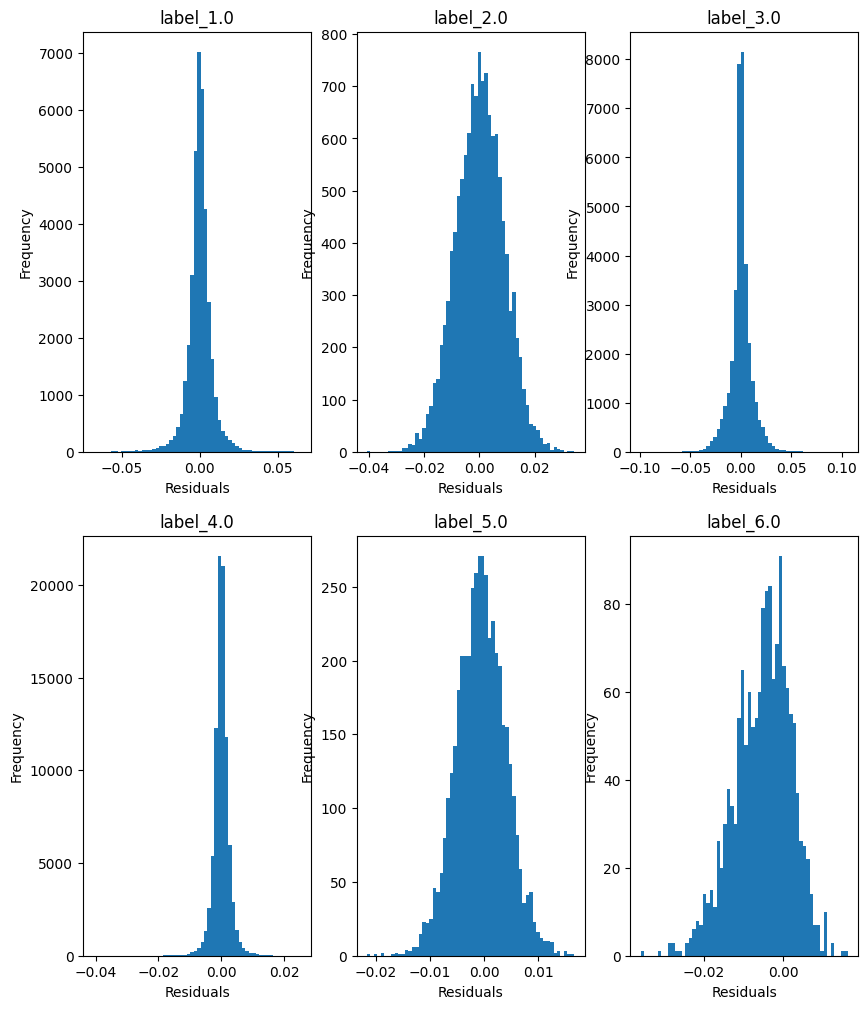

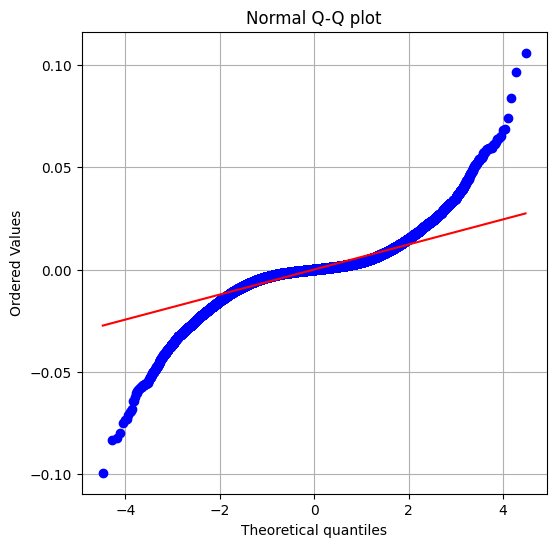

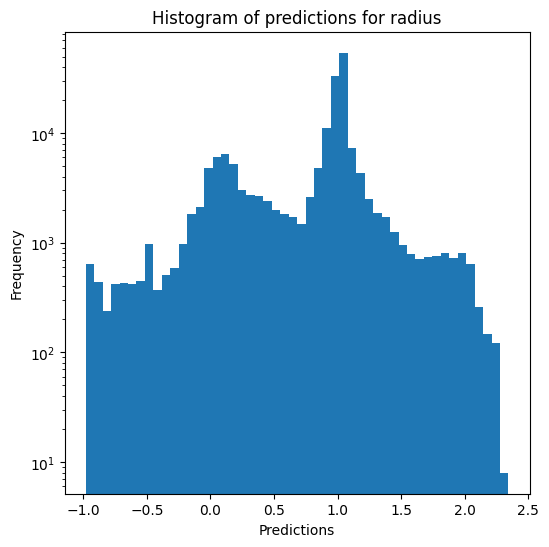

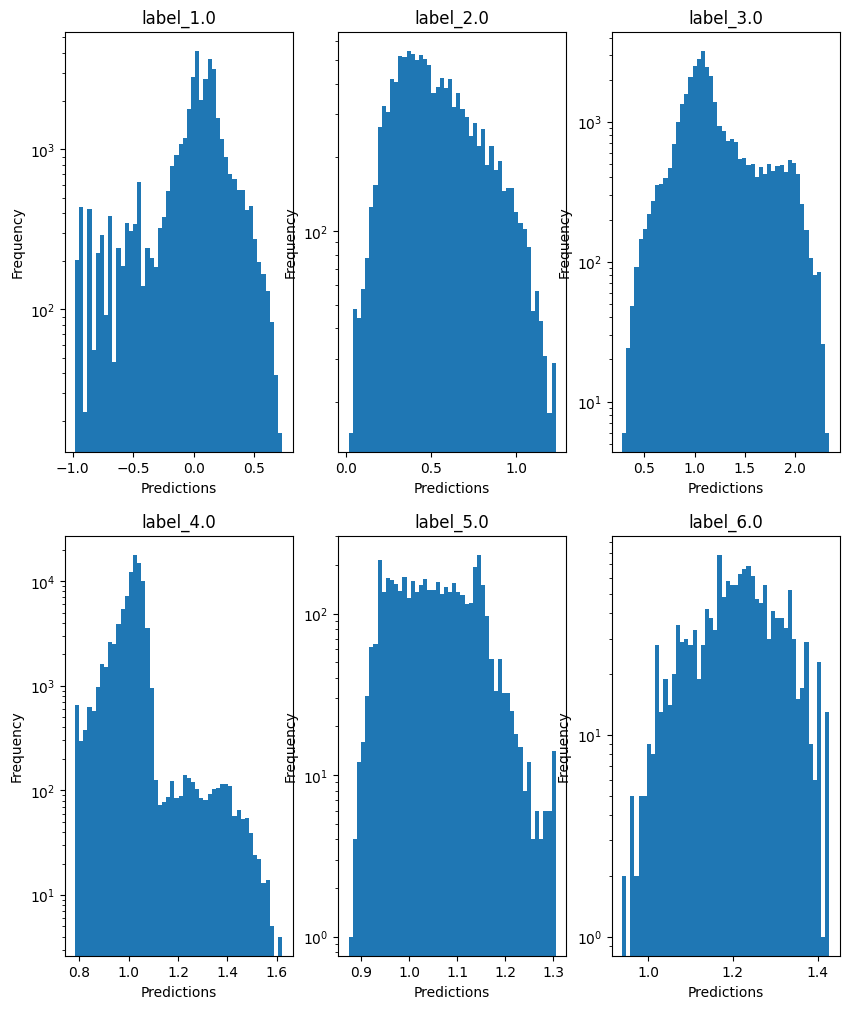

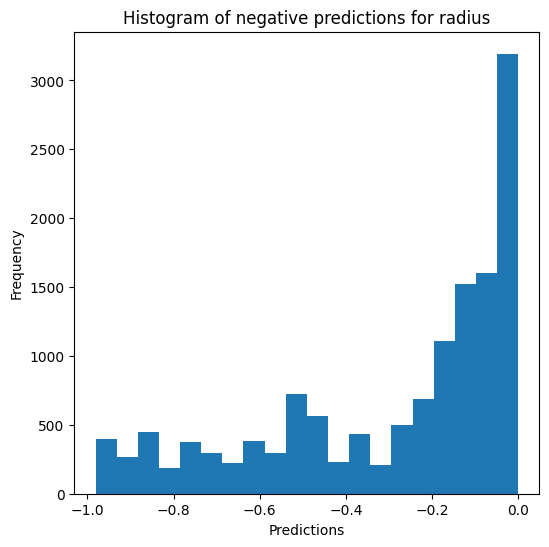

Saving predictions and results...
True
True
True
True


In [ ]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, n_jobs=5)

### Multi-layer perceptron

In [20]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Performing K-fold...
Split 1 0.00047277751039866985
2 0.00047254127758030237
3 0.00044396374239762565
4 0.0005386705148175431
5 0.00044028094318133325

Evaluating predictions...
no negative values

mass results for the label category with a value of 1.0
  value range :  0.09 - 2.999
  RVE :  0.9959413312589612
  RMSE :  0.04512281166038729
  MAE :  0.032799531764147266
  MedAE :  0.02349955432136208
  CORR :  0.9980929605760922
  MAX_ER :  0.3072140732316573
  Percentiles : 
    75th percentile :  0.045748413779013564
    90th percentile :  0.07176914630195831
    95th percentile :  0.09323648963540175
    99th percentile :  0.14826487168976032

mass results for the label category with a value of 2.0
  value range :  0.726 - 2.996
  RVE :  0.9945807875223214
  RMSE :  0.04816486056185164
  MAE :  0.035365194476629745
  MedAE :  0.027034934691084755
  CORR :  0.9973159550216337
  MAX_ER :  0.26258076456827206
  Percentiles : 
    75th percentile :  0.0481042

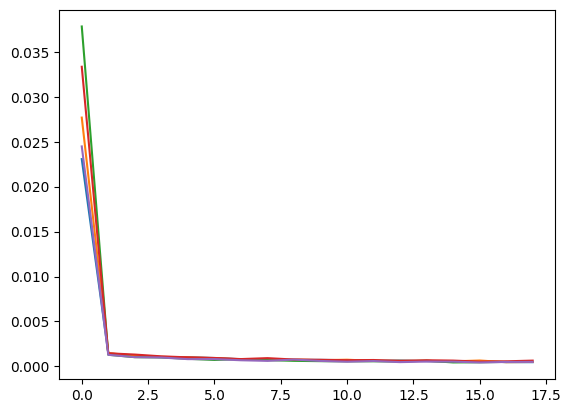

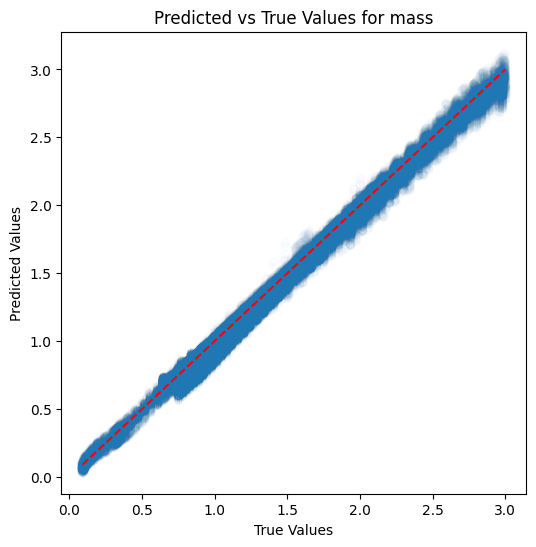

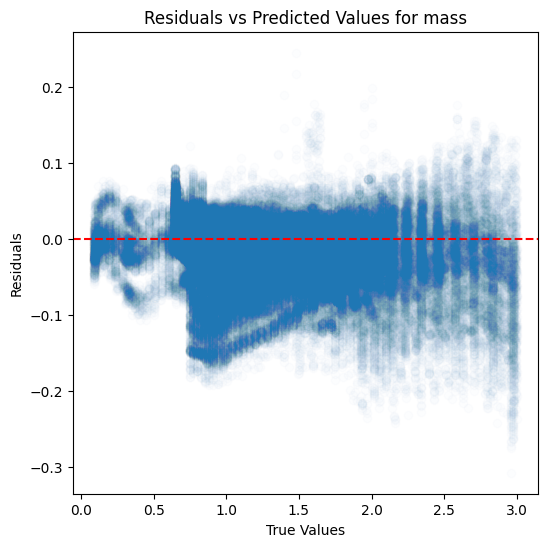

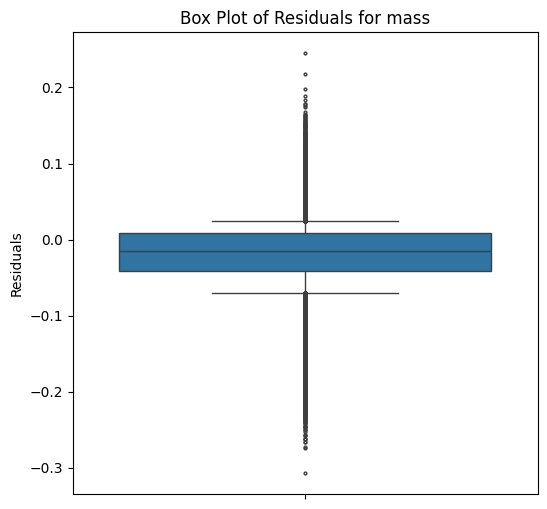

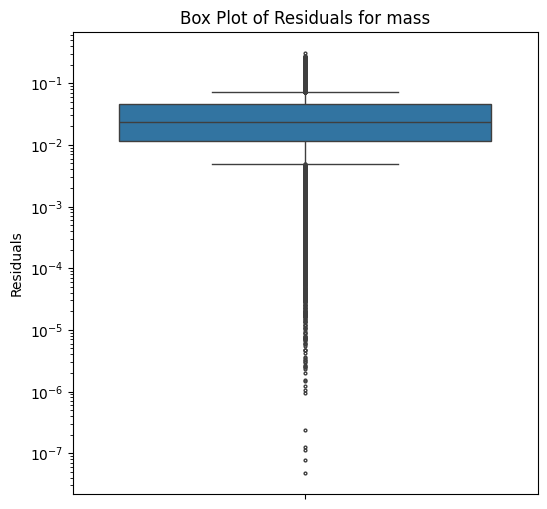

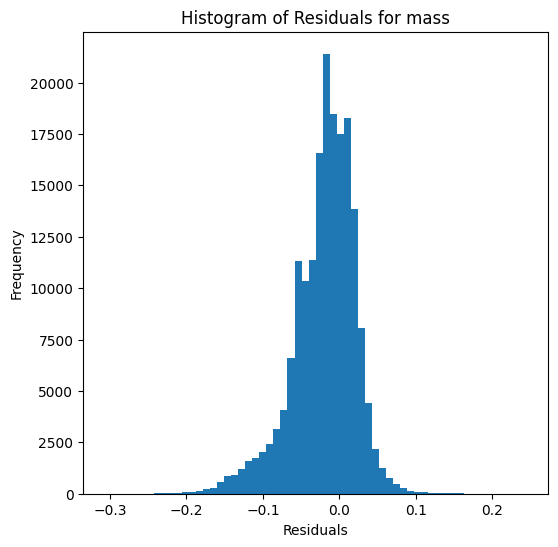

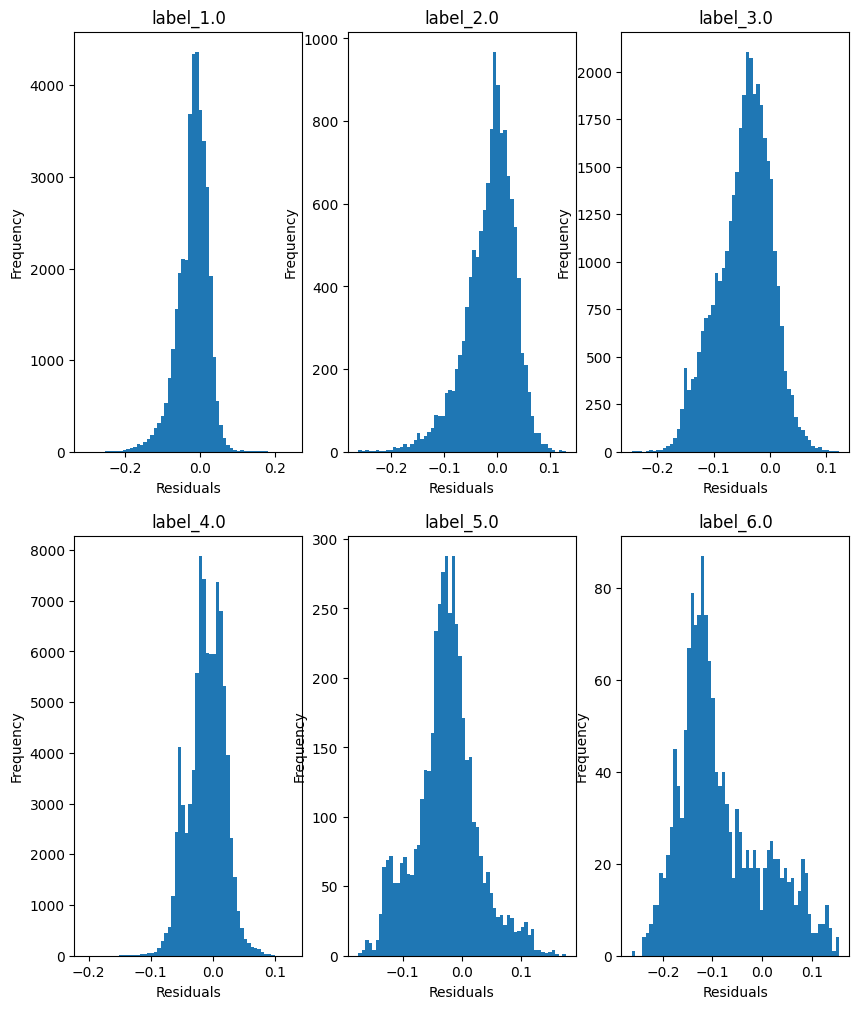

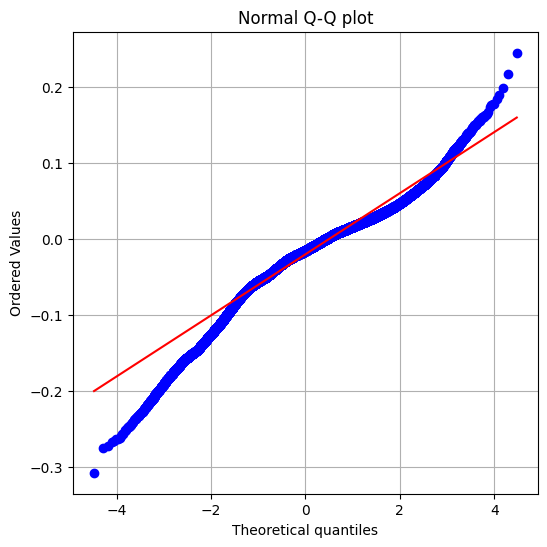

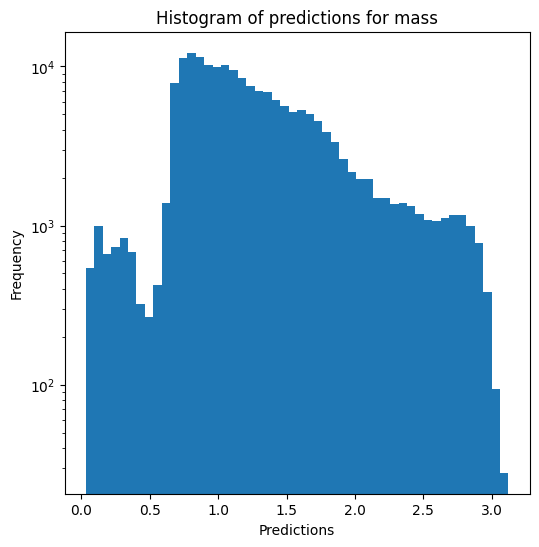

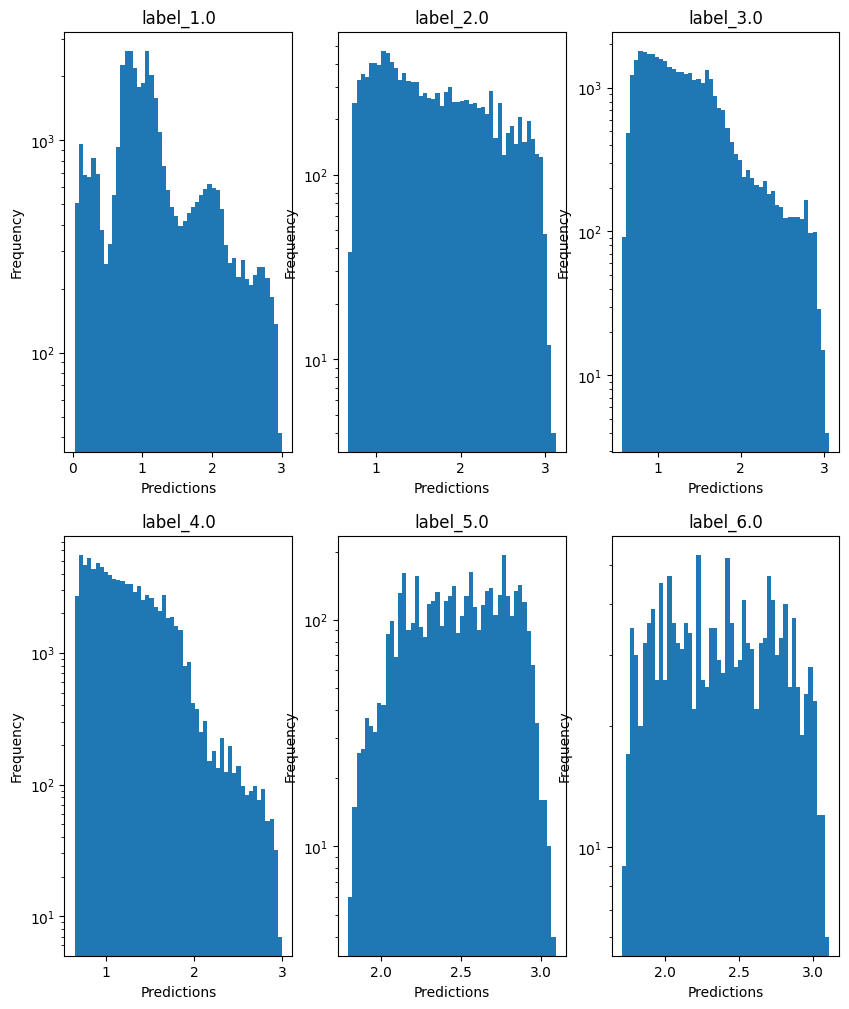


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 0.7228806106869394
  RVE :  0.9966608938106034
  RMSE :  0.018382740155483208
  MAE :  0.013181100180723018
  MedAE :  0.008761311593608564
  CORR :  0.9983438565505195
  MAX_ER :  0.08736854702223901
  Percentiles : 
    75th percentile :  0.017958226380505135
    90th percentile :  0.03324539611608014
    95th percentile :  0.03871347063889273
    99th percentile :  0.054542518123409746

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 1.2289134059946882
  RVE :  0.9939856611231387
  RMSE :  0.019648350972958042
  MAE :  0.015137915792858614
  MedAE :  0.011578846006440074
  CORR :  0.9969882969346686
  MAX_ER :  0.07449609487630049
  Percentiles : 
    75th percentile :  0.021362018430780172
    90th percentile :  0.033610139457689876
    95th percentile :  0.03952863902931019
    99th percentile :  0.055221999047867426

radius results for 

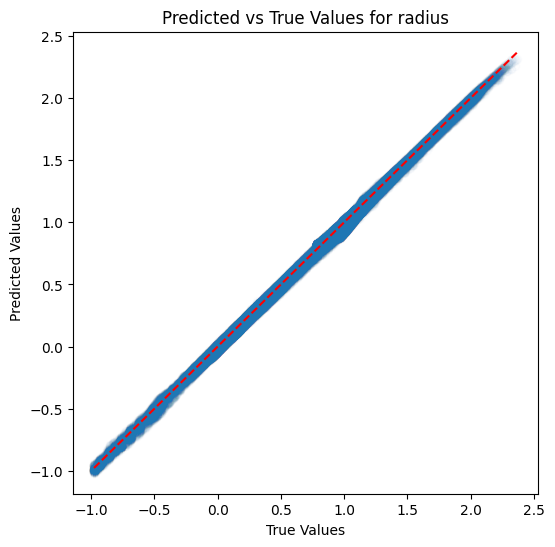

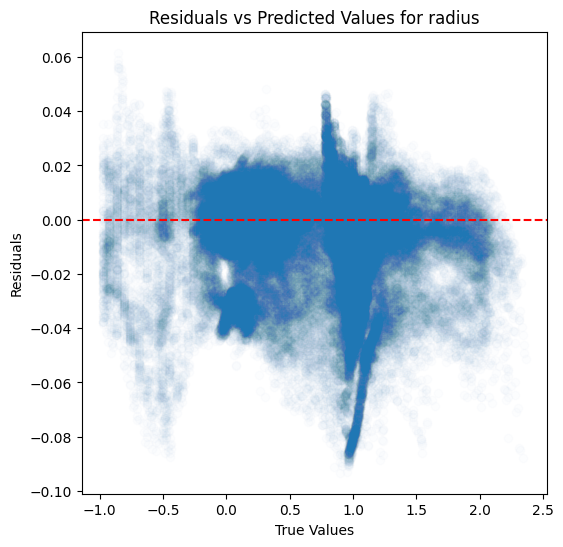

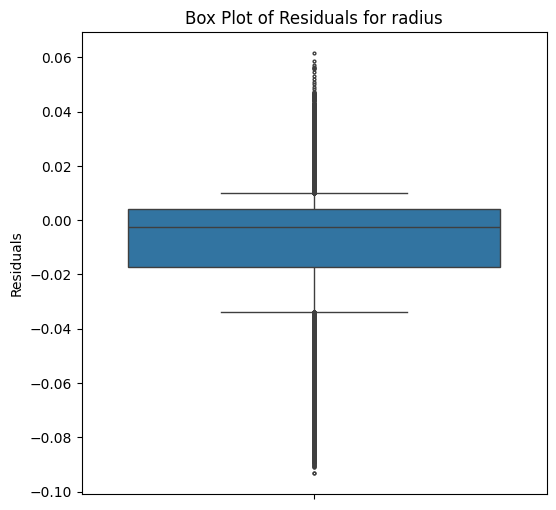

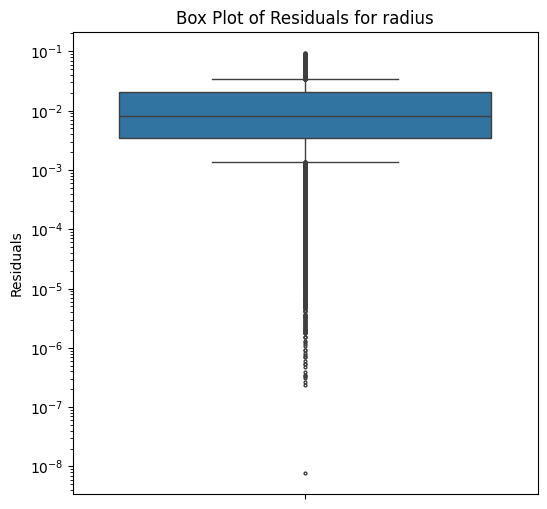

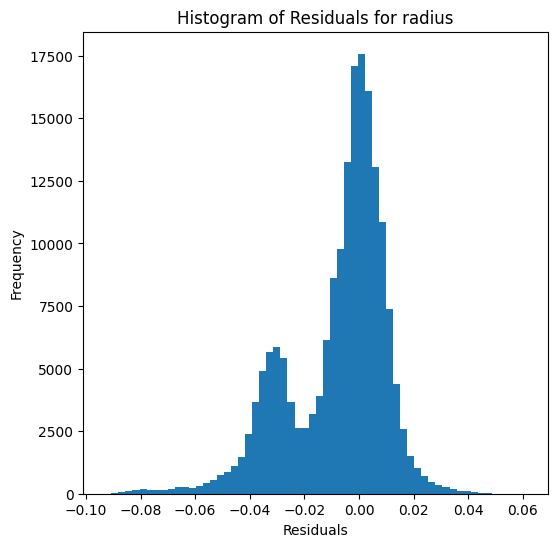

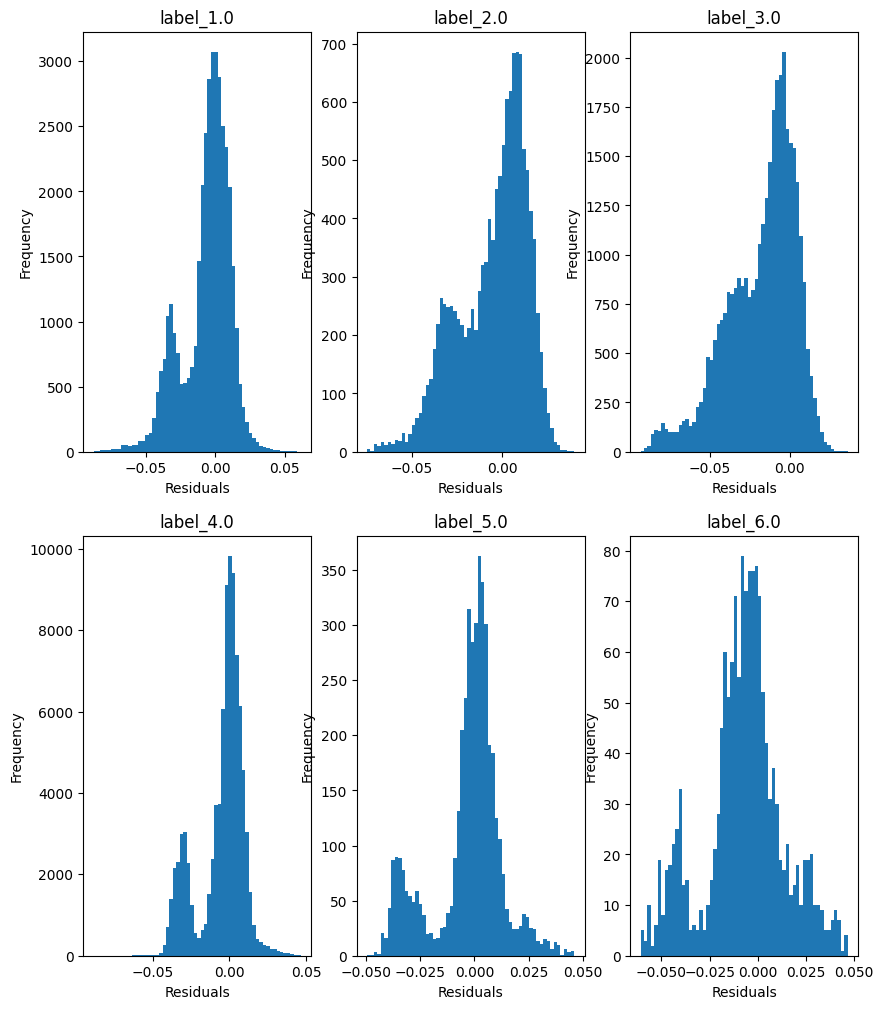

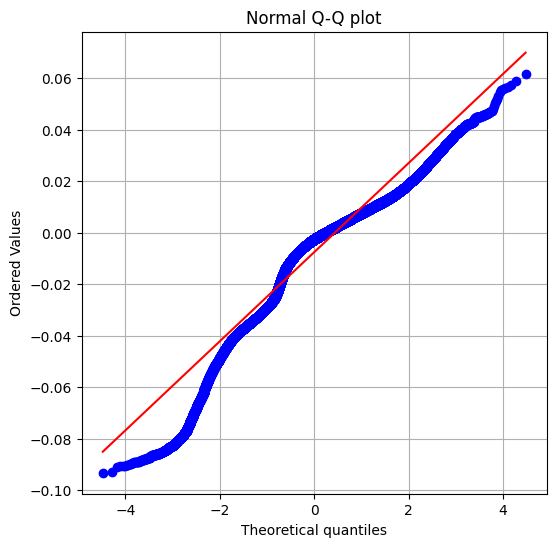

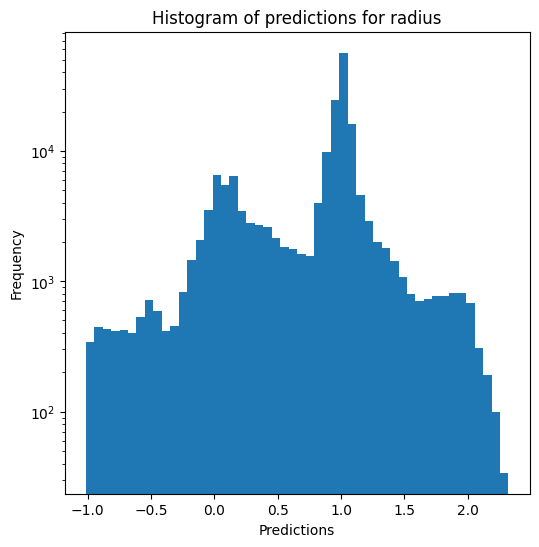

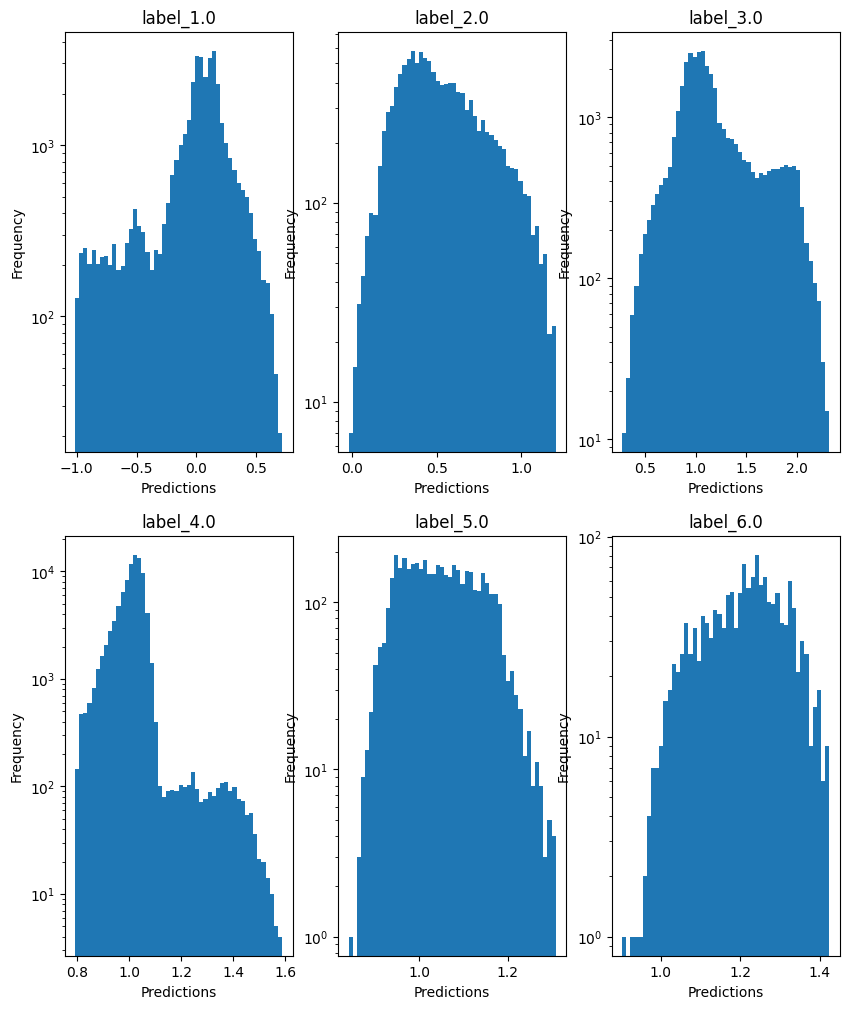

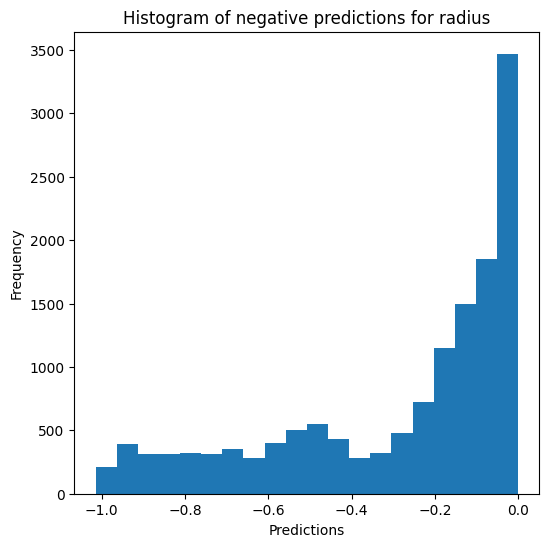

Saving predictions and results...
True
True
True
True


In [ ]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400) #, override=False, use_preds=True)